In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from typing import Union

# Assumes Coach, pyplane, I1cal, I2cal are already available in the notebook environment

def _freq_to_current(freq_hz: Union[float, np.ndarray], fit_coeffs: np.ndarray) -> np.ndarray:
    """Convert C2F frequency(ies) in Hz to current(s) using polynomial fit coefficients."""
    freq_arr = np.asarray(freq_hz, dtype=float)
    return np.polyval(fit_coeffs, freq_arr)


def capture_ndp_differential(p, coarse, fine: int, dv: np.ndarray, vcm: float,
                             i1cal: np.ndarray, i2cal: np.ndarray):
    """
    Perform a true differential sweep keeping common-mode fixed: v1 = vcm + dv/2, v2 = vcm - dv/2.

    Returns (i1, i2, v1_set, v2_set, ib) where v*_set are the quantized voltages actually set.
    """
    dv = np.asarray(dv, dtype=float)
    v1_vec = vcm + 0.5 * dv
    v2_vec = vcm - 0.5 * dv

    i1_list = []
    i2_list = []
    v1_set_list = []
    v2_set_list = []

    ib = p.set_ndp_ib(coarse, fine)

    for v1, v2 in zip(v1_vec, v2_vec):
        v1_set_list.append(p.set_ndp_v1(v1))
        v2_set_list.append(p.set_ndp_v2(v2))
        time.sleep(0.1)
        fs = p.measure_c2f_freqs(0.1)
        i1_list.append(_freq_to_current(fs[p.NDP_I1_C2F_CHANNEL], i1cal))
        i2_list.append(_freq_to_current(fs[p.NDP_I2_C2F_CHANNEL], i2cal))

    i1 = np.asarray(i1_list)
    i2 = np.asarray(i2_list)
    v1_set = np.asarray(v1_set_list)
    v2_set = np.asarray(v2_set_list)

    return i1, i2, v1_set, v2_set, ib


# ==== 5.4.3 Sensitivity to input common-mode: run two Vcm values and overlay ====
# Configure your sweep. Adjust dv range and Vcm values for your setup if needed.
dv = np.linspace(-0.30, 0.30, 121)  # differential input sweep V1-V2
vcm_high = 1.10
vcm_low = 0.80  # choose small enough to potentially observe the Vmin effect

coarse = pyplane.Coach.BiasGenMasterCurrent.I30nA
fine = 255

plt.rcParams.update({"font.size": 12})

p = Coach(logging_level=logging.INFO)
p.open()
try:
    i1_hi, i2_hi, v1_hi, v2_hi, ib_hi = capture_ndp_differential(
        p, coarse, fine, dv, vcm_high, I1cal, I2cal
    )
    i1_lo, i2_lo, v1_lo, v2_lo, ib_lo = capture_ndp_differential(
        p, coarse, fine, dv, vcm_low, I1cal, I2cal
    )
finally:
    p.close()

# Plot overlays: I1/I2 vs dv and the differential current vs dv
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

axes[0].plot(dv, i1_hi, "b-", label=f"I1, Vcm={vcm_high:.2f} V")
axes[0].plot(dv, i2_hi, "b--", label=f"I2, Vcm={vcm_high:.2f} V")
axes[0].plot(dv, i1_lo, "r-", label=f"I1, Vcm={vcm_low:.2f} V")
axes[0].plot(dv, i2_lo, "r--", label=f"I2, Vcm={vcm_low:.2f} V")
axes[0].set_ylabel("Current (A)")
axes[0].set_title("I1 and I2 vs differential input (dv)")
axes[0].grid(True)
axes[0].legend(loc="best")

axes[1].plot(dv, i1_hi - i2_hi, "k-", label=f"I1 - I2, Vcm={vcm_high:.2f} V")
axes[1].plot(dv, i1_lo - i2_lo, "k--", label=f"I1 - I2, Vcm={vcm_low:.2f} V")
axes[1].set_xlabel("dv = V1 - V2 (V)")
axes[1].set_ylabel("Differential current (A)")
axes[1].set_title("Differential output vs dv at two Vcm values")
axes[1].grid(True)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()


Neuromorphic engineering I

## Lab 4: Static Circuits: Differential Pair, Bump-antibump Circuit


**Reminder: Did you `git pull` the exercises before starting this notebook?**

Team member 1:

Team member 2:

Board number:

Date:

------------------------------------------------------------------------------------------------------------------------------------------------------------

### Lab objectives

The objectives of this lab are to understand and characterize a number of useful standard
static circuits that in subthreshold operation.

The experimental objectives are as follows:
1. To see how neuromorphic chips are biased with a bias generator from [this paper](https://ieeexplore.ieee.org/document/6271979/).
1. To learn how to measure current using on-chip current-to-frequency (**C2F**) converters from [this paper](http://dx.doi.org/10.1109/BioCAS.2016.7833756).
2. To measure and characterize the differential-pair currents as a function of the input voltages, including the mismatch-caused differential offset voltage, linear range, common-mode voltage effect, and Early effect.
3. To characterize a bump-antibump circuit from [this paper](https://doi.org/10.1109/IJCNN.1991.155225), and to understand something about one of its non-idealities.

# 1 Reading

Read the section on the differential pair, transconductance amplifier, and bump circuit in
Chapter 5 of the class book.

# 2 Prelab

_This prelab must be completed before coming to the lab._

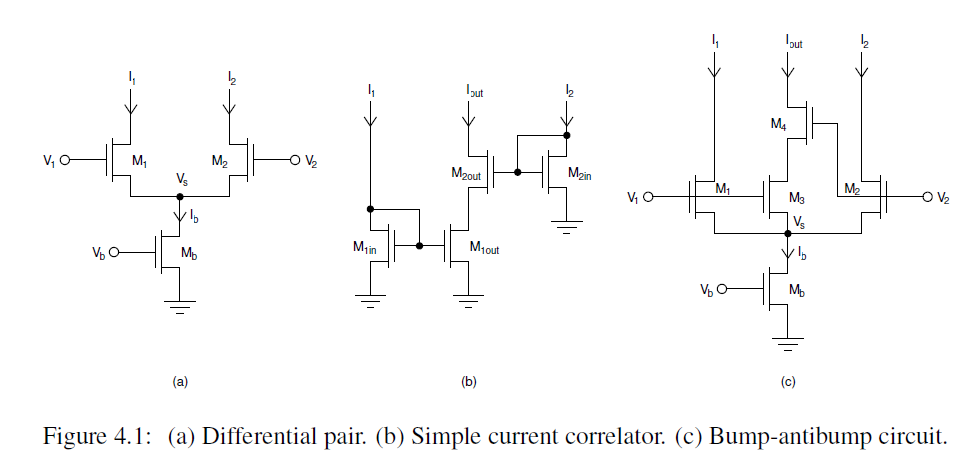

## 2.1 Differential pair

All parts of this question refer to the differential pair shown in Fig. 4.1(a). Unless stated otherwise, assume that $M_1$, $M_2$, and $M_b$ are in saturation, that they are operated in subthreshold.

When working with differential circuits, it is often advantageous to express results in terms of the _common mode_ voltage (denoted by $\bar V$ or $V_{cm}$) and the _differential mode_ voltage (denoted by $\delta V$ or $V_{dm}$). These voltages are defined in terms of $V_1$ and $V_2$ by $\bar V \equiv \frac{1}{2}\left(V_1+V_2\right)$ and $\delta V \equiv V_1-V_2$. 

<font color=#108ee9 markdown="1">

*  Solve for $V_1$ and $V_2$ in terms of  $\bar V$ and $\delta V$.
</font>

By definition:
$$
\bar V = \frac{1}{2}(V_1 + V_2), \qquad \delta V = V_1 - V_2
$$

Solving for $V_1$ and $V_2$:
$$
\begin{aligned}
V_1 &= \bar V + \frac{\delta V}{2},\\[4pt]
V_2 &= \bar V - \frac{\delta V}{2}.
\end{aligned}
$$

<font color=#108ee9 markdown="1">

* Compute the common source voltage $V_s$ of $M_1$ and $M_2$ as a function of the inputs $V_1$ and $V_2$, and the bias current $I_b$.
</font>

In weak inversion, the drain current of a saturated MOSFET is:
$$
I = I_0\cdot e^{\left(\dfrac{\kappa\cdot(V_g - V_s)}{U_T}\right)}
$$

Hence for the differential pair:
$$
\begin{aligned}
I_1 &= I_0\cdot e^{\left(\dfrac{\kappa(V_1 - V_s)}{U_T}\right)},\\
I_2 &= I_0\cdot e^{\left(\dfrac{\kappa(V_2 - V_s)}{U_T}\right)},\\
\\
I_b &= I_1 + I_2.
\end{aligned}
$$

Substitute and solve for $V_s$:
$$
I_b = I_0\cdot e^{-\frac{\kappa V_s}{U_T}}\!\left(e^{\frac{\kappa V_1}{U_T}} + e^{\frac{\kappa V_2}{U_T}}\right)
$$


$$
V_s = \frac{U_T}{\kappa}
\ln\!\left(\frac{I_0 \left(e^{\frac{\kappa V_1}{U_T}} + e^{\frac{\kappa V_2}{U_T}}\right)}{I_b}\right)
$$

Subtitute for V1 and V2 to get equation in terms of $\bar V$ and $\delta V$:
$$
V_s = \frac{U_T}{\kappa} \cdot \ln \cdot \left(\frac{2\cdot I_0\cdot e^{\frac{\kappa\bar V}{U_T}}\cosh\!\left(\dfrac{\kappa\delta V}{2U_T}\right)}{I_b}\right)
$$

<font color=#108ee9 markdown="1">

* What restrictions would you put on $V_1$ and $V_2$ to ensure that $M_b$ is in saturation?
</font>

For the bias transistor $M_b$ (gate $V_b$, drain $V_s$, source $0$):

$$
V_{DS,b} = V_s - 0 = V_s
$$

To ensure saturation:

$$
V_{DS,b} \ge 3U_T \quad\text{(the weak inversion saturation condition)}
$$

or equivalently, in the strong inversion form:
$$
V_s \ge V_b - V_T
$$

That then means that $V_1$ and $V_2$ must not cause $V_s$ to fall below these limits.


* <font color=#108ee9> Sketch </font> $V_s$ versus $V_2$, while holding $V_1$ constant.

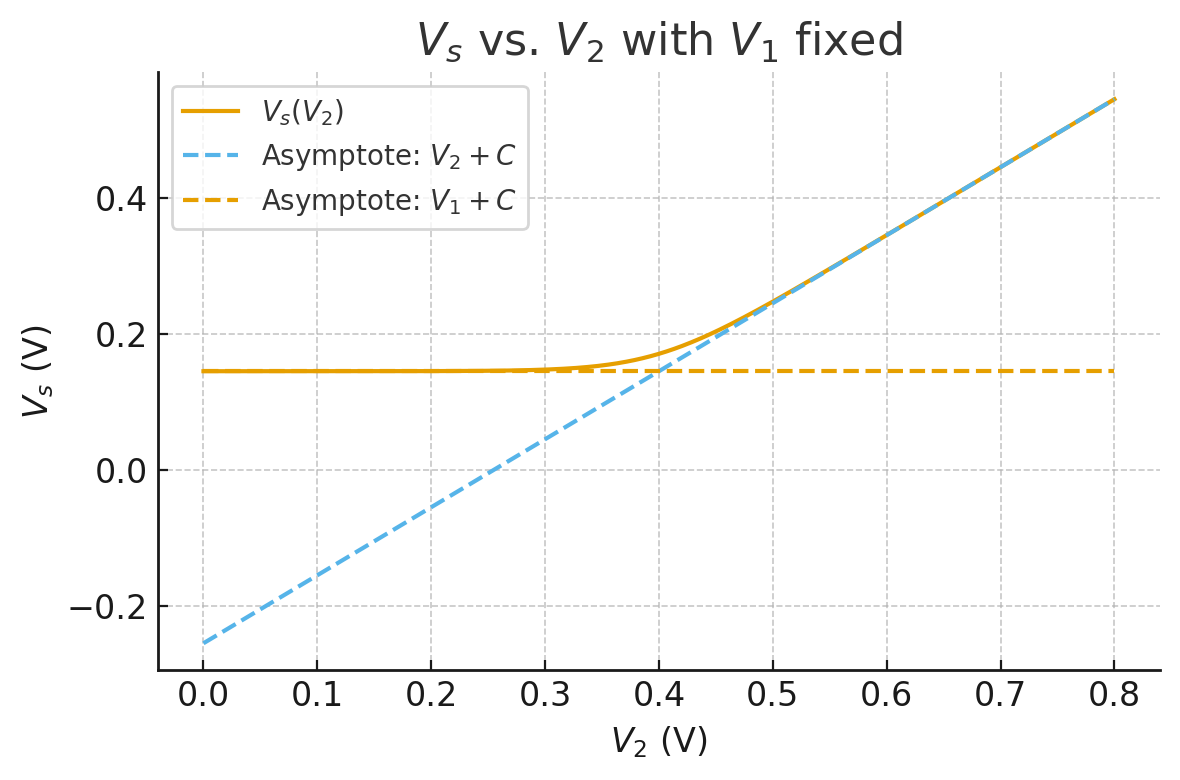

* <font color=#108ee9>How is the diff-pair related to a source-follower?</font>

Each input transistor, $M_1$ and $M_2$, functions as a source follower because the voltage at the common source node, $V_s$, increases with either input voltage. The differential pair can then be seen as two linked source followers that share a common current source, $M_b$.

* <font color=#108ee9>In what way </font> does $V_s$ approximate the maximum function $\max\left(V_1,V_2\right)$? (You will see why this is relevant in the winner-take-all circuit.)

From part (2):
$$
V_s = \frac{U_T}{\kappa}\ln\!\left(e^{\frac{\kappa V_1}{U_T}} + e^{\frac{\kappa V_2}{U_T}}\right)
- \frac{U_T}{\kappa}\ln\!\left(\frac{I_b}{I_0}\right)
$$

Using the identity
$$
\ln(e^a + e^b) = \max(a,b) + \ln\!\left(1 + e^{-|a-b|}\right)
$$

we obtain:
$$
V_s = \max(V_1,V_2)
+ \frac{U_T}{\kappa}\ln\!\left(1 + e^{-\frac{\kappa|V_1 - V_2|}{U_T}}\right)
- \frac{U_T}{\kappa}\ln\!\left(\frac{I_b}{I_0}\right)
$$

Hence, $V_s$ acts as a smooth "soft-maximum" of $V_1$ and $V_2$.

* <font color=#108ee9>Compute the currents </font> $I_1$ and $I_2$ as a function of $V_1$, $V_2$, and $I_b$.

We have:
$$
\frac{I_1}{I_2} = e^{\frac{\kappa(V_1 - V_2)}{U_T}}, \qquad I_1 + I_2 = I_b
$$

Solving this system:
$$
\begin{aligned}
I_1 &= I_b \frac{e^{\frac{\kappa V_1}{U_T}}}{e^{\frac{\kappa V_1}{U_T}} + e^{\frac{\kappa V_2}{U_T}}},\\[4pt]
I_2 &= I_b \frac{e^{\frac{\kappa V_2}{U_T}}}{e^{\frac{\kappa V_1}{U_T}} + e^{\frac{\kappa V_2}{U_T}}}.
\end{aligned}
$$

Then if we what them in terms of $\bar V$ and $\delta V$, we can continue the substitution and simplify to get:
$$
\begin{aligned}
I_1 &= \frac{I_b}{2}\!\left[1 + \tanh\!\left(\frac{\kappa\,\delta V}{2U_T}\right)\right],\\[4pt]
I_2 &= \frac{I_b}{2}\!\left[1 - \tanh\!\left(\frac{\kappa\,\delta V}{2U_T}\right)\right].
\end{aligned}
$$

* <font color=#108ee9>Now compute the relationship </font> between the differential output current $I_1 - I_2$ and the differential input voltage $\delta V$. Remember there is a trick: multiplying by $\exp(-\frac{V_1+V_2}{2})$.

Starting from the expressions above:
$$
I_1 - I_2 = I_b \cdot \frac{e^{\frac{\kappa V_1}{U_T}} - e^{\frac{\kappa V_2}{U_T}}}{e^{\frac{\kappa V_1}{U_T}} + e^{\frac{\kappa V_2}{U_T}}}
$$
Multiply numerator and denominator by $e^{-\frac{\kappa}{2U_T}(V_1+V_2)}$:
$$
I_1 - I_2 = I_b \cdot \frac{2\sinh\left(\frac{\kappa\delta V}{2U_T}\right)}{2\cosh\left(\frac{\kappa\delta V}{2U_T}\right)}
$$
Therefore:
$$
I_1 - I_2 = I_b \cdot \tanh\left(\frac{\kappa\,\delta V}{2U_T}\right)
$$
This represents the well-known "tanh law" for the subthreshold differential pair.

* <font color=#108ee9>Sketch a graph </font> of $I_1$ and $I_2$ versus $\delta V$. Also sketch the sum $I_1 +I_2$ and the difference $I_1-I_2$ on the same axes.

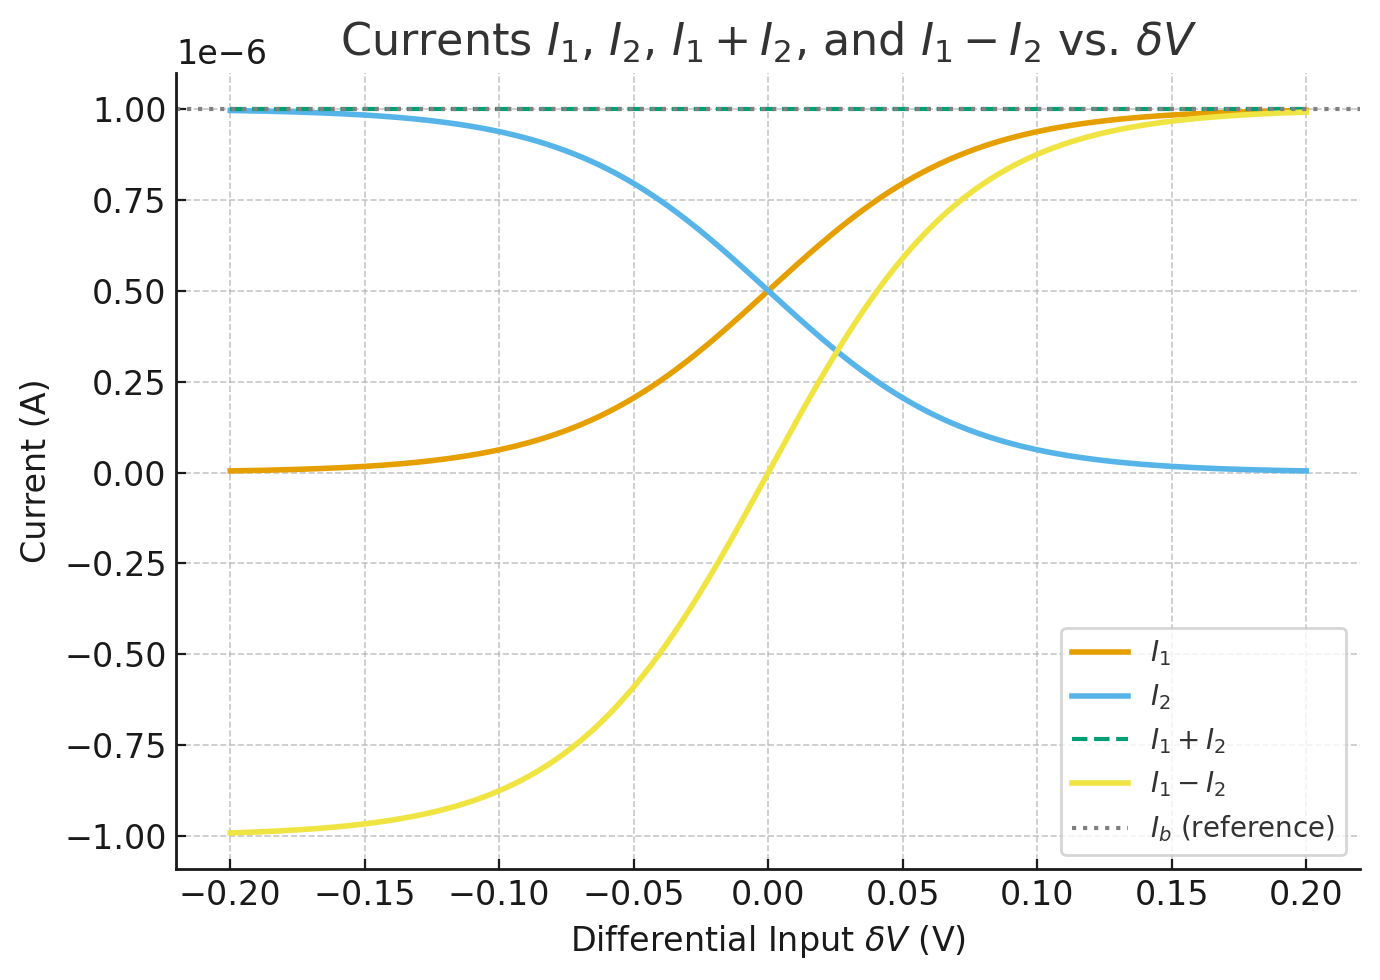

## 2.2 Current correlator

For the simple current correlator in Fig. 4.1(b).

* <font color=#108ee9>Show that </font> $I_{\rm out} = \frac{rI_1I_2}{I_1+I_2}$, where all the $W/L$ ratios for the transistors are identical except that the middle transistors $M_{\rm out1,2}$ are $r$ times stronger than the outer ones, i.e. have $W/L$ that is $r$ times more than the outer transistors $M_{\rm in1,2}$. Assume that the top transistor $M_{\rm 2out}$ is in saturation, but note that the bottom one, $M_{\rm 1out}$, may not be.

With diodes $(M_{\text{in1}})$ and $(M_{\text{in2}})$ connected and biased by currents $(I_1)$ and $(I_2)$, their gate voltages $(V_{g1})$ and $(V_{g2})$ satisfy the following equations (where the strength is $(I_0)$ for unit devices):

$$
I_1 = I_0\,\exp\left(\frac{\kappa V_{g1}}{U_T}\right), \qquad I_2 = I_0\,\exp\left(\frac{\kappa V_{g2}}{U_T}\right).
$$

From these equations, we can derive:

$$
e^{\frac{\kappa V_{g1}}{U_T}} = \frac{I_1}{I_0}, \qquad e^{\frac{\kappa V_{g2}}{U_T}} = \frac{I_2}{I_0}.
$$

### Middle Devices

The middle transistors $M_{\text{out1}}$ and $M_{\text{out2}}$, which are $r$ times stronger, share the same gate voltages $V_{g1}$ and $V_{g2}$, respectively. We denote the series connection point between them as $V_x$. Assume that $M_{\text{out2}}$ (the upper device) is in saturation (meaning that $1 - e^{-V_{DS}/U_T} \approx 1$), while $M_{\text{out1}}$ (the lower device) may have a finite drain-to-source voltage $V_{DS} = V_x$.

The currents, which flow downward and are equal to $I_{\text{out}}$ in series, can be expressed using the subthreshold law as follows:

$$
\begin{aligned}
I_{\text{out}} &= r I_0\,\exp\left(\frac{\kappa V_{g2}}{U_T}\right) && \text{(top device in saturation)} \\
&= r I_0\,\exp\left(\frac{\kappa V_{g1}}{U_T}\right) (1 - e^{-V_x/U_T}) && \text{(bottom device, finite $V_{DS} = V_x$)}.
\end{aligned}
$$

we can continue by substituting the diode relations, to rewrite these equations as:

$$
I_{\text{out}} = r I_2, \qquad I_{\text{out}} = r I_1 (1 - e^{-V_x/U_T}).
$$

This leads to the relationship:

$$
1 - e^{-V_x/U_T} = \frac{I_{\text{out}}}{r I_1} = \frac{I_2}{I_1} \quad \Rightarrow \quad e^{-V_x/U_T} = 1 - \frac{I_2}{I_1} = \frac{I_1 - I_2}{I_1}.
$$

### Symmetric Elimination

By symmetry, we can interchange the labels, considering the lower device as saturated and the upper device having a finite drain-to-source voltage $V_{DS} = V_{DD} - V_x$ (whose exponential factor $e^{-(V_{DD} - V_x)/U_T} \approx 0$ in saturation). Performing the analogous steps yields:

$$
I_{\text{out}} = r I_1, \qquad I_{\text{out}} = r I_2(1 - e^{-(V_{DD} - V_x)/U_T}) \approx r I_2.
$$

By eliminating $V_x$ between the two equations that account for the finite drain-to-source voltages, we can write a single current continuity relation. This leads to the unique $I_{\text{out}}$ that is compatible with both finite $V_{DS}$ corrections:

$$
I_{\text{out}} = \frac{r I_1 I_2}{I_1 + I_2}.
$$

This expression is the harmonic mean multiplied by $r$, representing the series combination of two subthreshold "conductances" proportional to $I_1$ and $I_2$.

* Let $I_1 = \frac{I_t}{2} (1+x), I_2 = \frac{I_t}{2} (1-x)$, where total current $I_t \equiv I_1 + I_2$ is the total input current and $x \equiv \frac{I_1 - I_2}{I_t}$ is a dimensionless difference current.

**(a)** <font color=#108ee9>Substitute these expressions </font> into the expression for $I_{out}$ in exercise 2 and obtain an expression for $I_{out}$ in terms of $I_t$ and $x$.

Substitute into the result of Part~1:
$$
\begin{aligned}
I_{\rm out}
&=\frac{r\;\big[\frac{I_t}{2}(1+x)\big]\big[\frac{I_t}{2}(1-x)\big]}
{\frac{I_t}{2}(1+x)+\frac{I_t}{2}(1-x)}
= \frac{r\;\frac{I_t^2}{4}(1-x^2)}{I_t}\\[4pt]
&=\boxed{\; \frac{r\,I_t}{4}\,(1-x^2)\; }.
\end{aligned}
$$

**(b)** <font color=#108ee9>Sketch a graph</font> of $I_{out}$ vs. $x$.

(It might be simpler to plot it, but think about the range of $x$.)


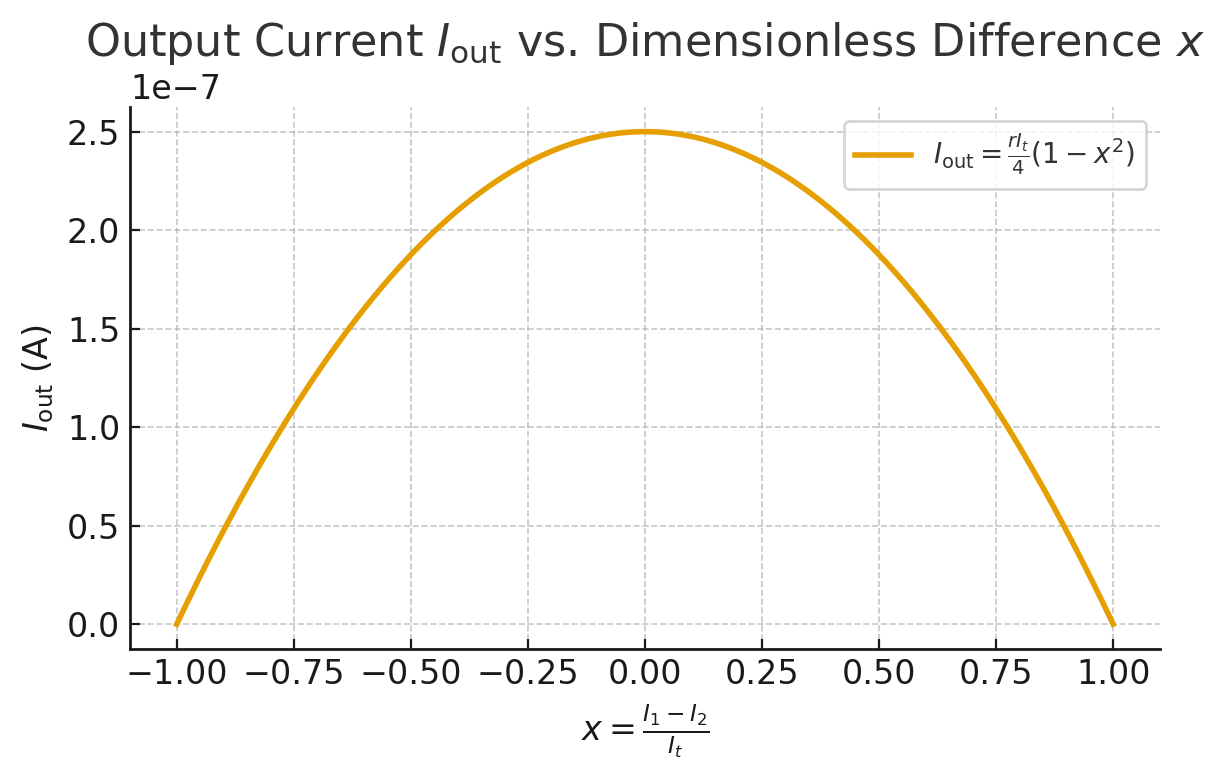

Not sure what to make of this result.. direction is not clear yet.

**(c)** <font color=#108ee9>Show </font> that if $I_1$ and $I_2$ are generated by a differential pair (see question 2.1) then the dimensionless difference current $x \equiv \frac{I_1 - I_2}{I_t} = \tanh\left( \frac{\kappa\left(V_1-V_2\right)}{2U_T} \right)$ and $I_t$ is the differential pair’s bias current.

if $I_1$ and $I_2$ are trully produced by a weak-inversion differential pair, with inputs $V_1,V_2$ and a bias current $I_b$, then:
$$
I_1=\frac{I_b}{2}\!\left[1+\tanh\!\Big(\frac{\kappa(V_1-V_2)}{2U_T}\Big)\right],\quad
I_2=\frac{I_b}{2}\!\left[1-\tanh\!\Big(\frac{\kappa(V_1-V_2)}{2U_T}\Big)\right].
$$
We can then say that the total current is
$$
I_t=I_1+I_2=I_b,
$$
and the (dimmensionless) difference current is
$$
x=\frac{I_1-I_2}{I_t}
=\tanh\!\Big(\frac{\kappa(V_1-V_2)}{2U_T}\Big).
$$
We continue by substituting $I_t=I_b$ and $x$ into 2(a), yielding:
$$
\begin{align}
I_{\rm out}&=\frac{r I_b}{4}\Big[1-\tanh^2\!\Big(\frac{\kappa(V_1-V_2)}{2U_T}\Big)\Big]\\
\\
&=\frac{r I_b}{4}\,\operatorname{sech}^2\!\Big(\frac{\kappa(V_1-V_2)}{2U_T}\Big).
\end{align}
$$

## 2.2 Bump-antibump circuit

Now consider the bump-antibump circuit shown in Fig. 4.1(c) from [this paper](https://doi.org/10.1109/IJCNN.1991.155225):

*  <font color=#108ee9>Compute  </font> $I_{out}$ in terms of
$x$, $r$, and $I_b$ by substituting $I_t = I_b-I_{out}$ in the equation for $I_{out}$ in exercise 2 and solving for $I_{out}$.
Assume that  $x = \tanh\left( \frac{\kappa\left(V_1-V_2\right)}{2U_T} \right)$.

From the correlator (Exercise~2), the output current is
$$
I_{\text{out}} = \frac{r I_t}{4}(1 - x^2),
$$
where
$$
I_t = I_1 + I_2, \qquad x = \frac{I_1 - I_2}{I_t}.
$$
In the bump–antibump configuration, the total input current to the correlator is the remainder of
the bias current $I_b$ after the middle branch current $I_{\text{out}}$ is subtracted:
$$
I_t = I_b - I_{\text{out}}.
$$

Substitute this into the correlator equation:
$$
I_{\text{out}} = \frac{r}{4} (I_b - I_{\text{out}})(1 - x^2).
$$

Expand and collect $I_{\text{out}}$ terms:
$$
I_{\text{out}}\!\left[1 + \frac{r}{4}(1 - x^2)\right]
  = \frac{r I_b}{4}(1 - x^2).
$$

Solve for $I_{\text{out}}$:
$$
I_{\text{out}}
= \frac{\frac{r}{4}I_b(1 - x^2)}{1 + \frac{r}{4}(1 - x^2)}
= \frac{I_b(1 - x^2)}{\frac{4}{r} + 1 - x^2}.
$$

* <font color=#108ee9>Express your result in terms of the hyperbolic cosine function (cosh).</font> You may want to use the hyperbolic function relationships

\begin{equation}
\cosh^2(x)-\sinh^2(x)=1
\end{equation}
and
\begin{equation}
\tanh^2(x)=1-\frac{1}{\cosh^2(x)}
\end{equation}

You should end up with the result

\begin{equation}
I_{out}=\frac{I_b}{1+\frac{4}{r}\cosh^2(\frac{\kappa\Delta V}{2U_T})}
\end{equation}

---
For a differential pair, the dimensionless difference current is
$$
x = \tanh\!\left(\frac{\kappa(V_1 - V_2)}{2U_T}\right),
\quad\text{with}\quad
\Delta V = V_1 - V_2.
$$

Use the hyperbolic identities:
$$
\cosh^2(a) - \sinh^2(a) = 1, \qquad
\tanh^2(a) = 1 - \frac{1}{\cosh^2(a)}.
$$

Let $a = \frac{\kappa \Delta V}{2U_T}$, so that
$$
1 - x^2 = \operatorname{sech}^2(a) = \frac{1}{\cosh^2(a)}.
$$

Substitute into the previous expression:
$$
I_{\text{out}} = \frac{I_b \operatorname{sech}^2(a)}{\frac{4}{r} + \operatorname{sech}^2(a)}.
$$

Multiply numerator and denominator by $\cosh^2(a)$:
$$
I_{\text{out}} = \frac{I_b}{1 + \frac{4}{r}\cosh^2(a)}.
$$

Therefore,
$$
I_{\text{out}}
= \frac{I_b}{1 + \frac{4}{r}\cosh^2\!\left(\frac{\kappa\Delta V}{2U_T}\right)}.
$$

* <font color=#108ee9>What fraction </font> of $I_b$ will flow down the middle branch (the bump branch) if
  $V_1=V_2$? Should you make $r$ big or small to make most of the current flow down the middle branch for $\Delta V =0$?

At $\Delta V = 0$, $\cosh(0) = 1$. Thus:
$$
\frac{I_{\text{out}}}{I_b}
= \frac{1}{1 + \frac{4}{r}}
= \frac{r}{r + 4}.
$$

Hence, when $V_1 = V_2$, the fraction of the bias current flowing down the middle (bump) branch is $\tfrac{r}{r+4}$.
To make most of the current flow in this branch, choose \textbf{large $r$} (i.e., make the middle transistors stronger).


* <font color=#108ee9>Does the bump-antibump circuit compute ''soft'' or analog logic operations AND and XOR between the two voltage inputs </font>  $V_1$ and $V_2$?If so, in what way?

The bump–antibump circuit behaves as an analog "soft logic" gate:

The **bump output** (middle branch) current
    $$
    \frac{I_{\text{out}}}{I_b}
      = \frac{1}{1 + \frac{4}{r}\cosh^2\!\left(\frac{\kappa\Delta V}{2U_T}\right)}
    $$
    is maximal when $V_1 = V_2$ and decreases smoothly as $|\Delta V|$ increases.
    It therefore acts as a \textbf{soft XNOR} ("agreement detector") or equivalently a smooth AND-like operation that is large when both inputs are equal.

The **antibump output**
    $$
    I_{\text{anti}} = I_b - I_{\text{out}}
      = I_b\,\frac{\frac{4}{r}\cosh^2\!\left(\frac{\kappa\Delta V}{2U_T}\right)}
        {1 + \frac{4}{r}\cosh^2\!\left(\frac{\kappa\Delta V}{2U_T}\right)},
    $$
    is minimal when $V_1 = V_2$ and increases with $|\Delta V|$.
    This behaves as a \textbf{soft XOR} ("difference detector").

Thus, the bump–antibump circuit performs continuous-valued analog computations
corresponding to XNOR and XOR logic, with smooth transitions controlled by $\kappa$,
$U_T$, and the size ratio $r$.

# 4 Setup

You may want to install all the necessary requirements (python libraries). If it installs new packages, then restart the kernel.

In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt --upgrade # note upgrade to update jupyter-save-load-vars

ERROR: Ignored the following versions that require a different python version: 1.14.0 Requires-Python >=3.10; 1.14.0rc1 Requires-Python >=3.10; 1.14.0rc2 Requires-Python >=3.10; 1.14.1 Requires-Python >=3.10; 1.15.0 Requires-Python >=3.10; 1.15.0rc1 Requires-Python >=3.10; 1.15.0rc2 Requires-Python >=3.10; 1.15.1 Requires-Python >=3.10; 1.15.2 Requires-Python >=3.10; 1.15.3 Requires-Python >=3.10; 1.16.0 Requires-Python >=3.11; 1.16.0rc1 Requires-Python >=3.11; 1.16.0rc2 Requires-Python >=3.11; 1.16.1 Requires-Python >=3.11; 1.16.2 Requires-Python >=3.11; 2.1.0 Requires-Python >=3.10; 2.1.1 Requires-Python >=3.10; 2.1.2 Requires-Python >=3.10; 2.1.3 Requires-Python >=3.10; 2.2.0 Requires-Python >=3.10; 2.2.1 Requires-Python >=3.10; 2.2.2 Requires-Python >=3.10; 2.2.3 Requires-Python >=3.10; 2.2.4 Requires-Python >=3.10; 2.2.5 Requires-Python >=3.10; 2.2.6 Requires-Python >=3.10; 2.3.0 Requires-Python >=3.11; 2.3.1 Requires-Python >=3.11; 2.3.2 Requires-Python >=3.11; 2.3.3 Requires-Pyt

## 4.1 Connect the device

Import necessary python libraries

In [1]:
import time # for time.sleep(seconds)
import numpy as np # numpy for arrays etc
from scipy import stats # for stats.linregress
import matplotlib
import matplotlib.pyplot as plt # for plotting
import matplotlib
plt.rcParams.update({'font.size': 12}) # make the detault font size larger for your readers
matplotlib.rcParams['pdf.fonttype'] = 42 # save fonts as type that are not outlined in illustrator or other drawing programs
from engineering_notation import EngNumber as ef # format numbers in engineering format quickly, e.g. ef(2e-9)='2n' https://pypi.org/project/engineering-notation/
from pathlib import Path # used for saving data

datapath = Path('data/lab4') # make a data folder to save your data called data/lab1
datapath.mkdir(parents=True, exist_ok=True)
from jupyter_save_load_vars import savevars, loadvars

import pyplane # for type hinting of biasgen constants
from ne1 import Coach # import Coach() class
import logging
p=Coach(logging_level=logging.INFO) # create a Coach object called p; you will use it to talk to class chip, change to logging.DEBUG for troubleshooting
# p.open()
# below lines are notebook magic for debugging, you can uncomment them when debugging the Coach() class
%load_ext autoreload
%autoreload explicit
%aimport ne1


Now try to open the board

In [3]:
p.open() # open the hardware interface to the board
p.close()

[INFO]: 2025-10-20 09:55:21,271 - NE1 - Opened CoACH at /dev/cu.usbmodem76219301 with firmware version (1, 12, 5) (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 175, in open)
[INFO]: 2025-10-20 09:55:21,272 - NE1 - closing device (deleting pyplane.Plane() object (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 250, in close)


If the above step fails, close the board and start over with replugging the board. Check the [Coach Chip troubleshooting hints](https://code.ini.uzh.ch/CoACH/CoACH-labs/-/blob/master/readme.md#troubleshooting-your-coach-chip-setup).


## 4.2 Select the multiplexer and demultiplexer

You may remember that in the last two labs, before we measure N-FET or P-FET we had to send a configuration event first.
That is because pin number has always been a bottleneck for IC design and we could not make a gigantic chip with hundreds of pins.
But on the other hand, the transistors are so tiny that we could put yet a lot more, so we decided to make some of the circuits share some input-output pins and a Current To Frequency (**C2F**) converter with multiple channels using analog mux/demux.
For more details please refer to the [chip documentation folder](https://drive.google.com/drive/folders/1VBPKVfS9zwu_I2ExR1D0jU2eCSgleoQG?usp=sharing) (not needed for the lab).  And see [Sec. 4.4](#44-current-to-frequency-ctf-current-measurement-circuit) that follows.

## 4.3 Bias Generator (BiasGen or BG)

For any analog circuit, you may need to set some fixed currents/voltages in order to put all transistors in the desired operation regime, which are called biases (e.g. $I_b$).
Since there are hundreds of biases on our chip that need to be set at the same time, it is impossible to just use a demultiplexer (as what we were doing when measuring N-FET and P-FET in the previous labs).

The way we are doing it (and also the way most neuromorphic chips work) is by having a so-called _Bias Generator_ (or _BiasGen_ in short) circuit, that outputs a current that can be divided and mirrored to each individual circuit.  See [this 2012 paper for the biasgen developed originally for DVS event cameras](https://ieeexplore.ieee.org/document/6271979/)  that is used on the CoACH chip. These bias generators are the end results of ideas published over [a period spanning 1965-2012](https://paperpile.com/shared/fRIuZh) that started with Bob Widlar in 1965 (the bootstapped mirror), continued with Bult and Geelen in 1992 (the current spliter), and occupied us for a period of about a decade (digitally programmable, ultra wide range bias current generators).

The basic idea is simple: Generate a PTAT (Proportional To Absolute Temperature) master current, and then split it down by powers of 2. Then combine copies of these currents, and mirror them with active buffers to the core of our chips. At the present time, we use a coarse-fine scheme, where a set of 8 coarse currents separated by a factor of about 8 are split by an 8-bit splitter. Users choose a coarse range and then select an 8-bit fraction of this coarse current as their bias current. 

The Widlar mirror and current splitter are sketched here, together with the actual layout of a 19-bias bias generator used on DAVIS event cameras: Theses bias generators are taught in NE2.

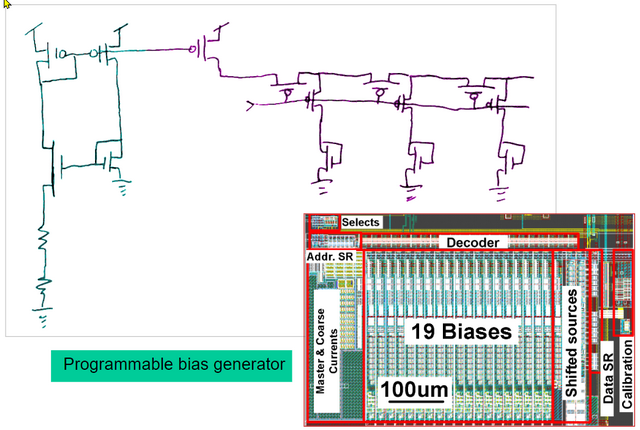



In a simplified form, the output of a branch of the BiasGen will be the gate voltage $V_b$ for the bias current $I_b$, and if the current mirror has a ratio of $w$ and the bias transistor operates in subthreshold-saturation:
\begin{equation}
I_b = w\frac{BG_{fine}}{256}I_{BG_{master}}
\end{equation}
Where $I_{\rm BG_{\rm master}}$ is the `BiasGenMasterCurrent` $\in \left\{ 60~\rm{pA}, 460~\rm{pA}, 3.8~\rm{nA}, 30~\rm{nA}, 240~\rm{nA} \right\}$, $BG_{\rm fine}$ is the integer fine value $\in [0, 256)$

To set a bias, use the Coach() function `setup_ndp()` (see 4.4 for examples). Specifically, here we use the semi-low-level Coach() function to address the diff pair bias `BiasAddress.NDP_VB_N`, set it be N-type BiasType.N, and program a coarse current `BiasGenMasterCurrent.I30nA` and fine value:
```
    current=p.set_bias(\
        pyplane.Coach.BiasAddress.NDP_VB_N,\
        pyplane.Coach.BiasType.N, \
        pyplane.Coach.BiasGenMasterCurrent.I30nA, fine_values[n])
```

## 4.4 Current-To-Frequency (**CTF**) current measurement circuit

To measure very small current (in our case from 1 pA to 10 nA), a very widely used method is called current-to-frequency conversion. The output frequency $f$ can be expressed as a function of input current $I$:
\begin{equation}
f = \frac{I}{C \Delta U}
\end{equation}
where $C$ is a capacitance that is charged by the input current, and $\Delta U$ is difference of the reference voltages where the circuit resets. For more details please the C2F paper linked above.

The actual circuit is shown here, lifted from [this paper about the C2F converter circuits](http://dx.doi.org/10.1109/BioCAS.2016.7833756):

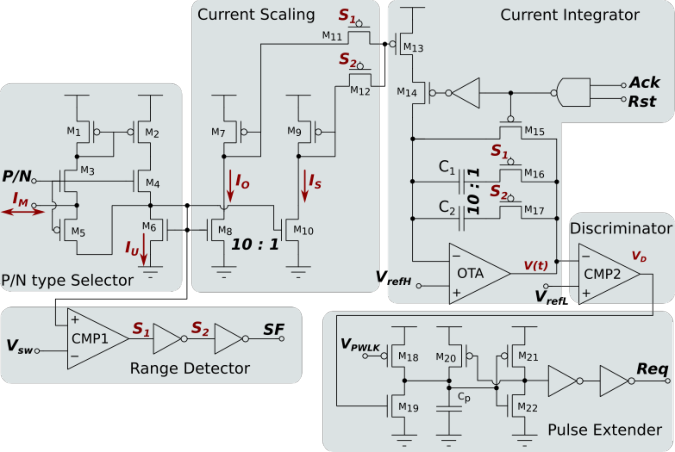

The monitored
current $I_M$ is rectified as $I_U$ , mirrored as $I_O$, and scaled down
as $I_S$. In parallel, the _Range Detector_ circuit evaluates $I_M$
and produces the signals S1 and S2 for integrating either $I_O$
on $C_1$ or $I_S$ on $C_2$ by transistors M11,12,16,17. The voltage
$V(t)$ gradually decreases during the integration phase, from its
initial value $V_{\rm refH}$; once $V(t)$ reaches $V_{\rm refL}$, it triggers a _Req_
pulse, of extended duration, regulated by the _Pulse Extender_
block. The integrator is reset once it receives an acknowledge
signal _Ack_, from an AER compatible receiver module, here the Teensy microcontroller.

* The output of the C2F circuit is a frequency-modulated series of _events_ that are counted by the Teensy microcontroller and sent to the PC.

As we can see from the figures from the paper, the circuit can measure a large range of currents as long as we have time to count the events.

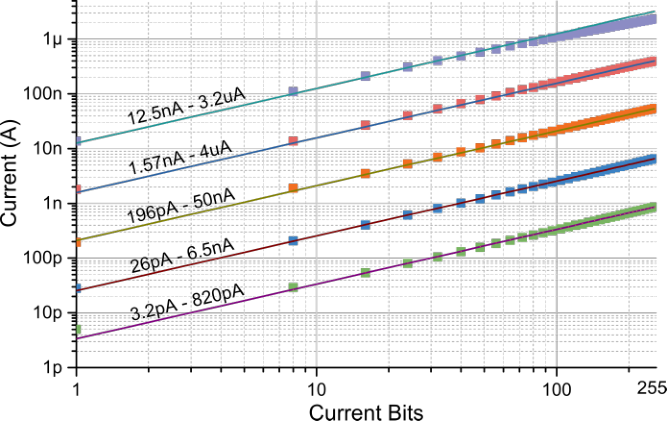

# 5 N-FET differential pair circuit (NDP)

In this experiment you will measure the dependence of the differential pair currents $I_1$ and $I_2$ on the differential input voltage $V_{\rm diff}=V_1-V_2$.

## 5.0 Schematic and pin map

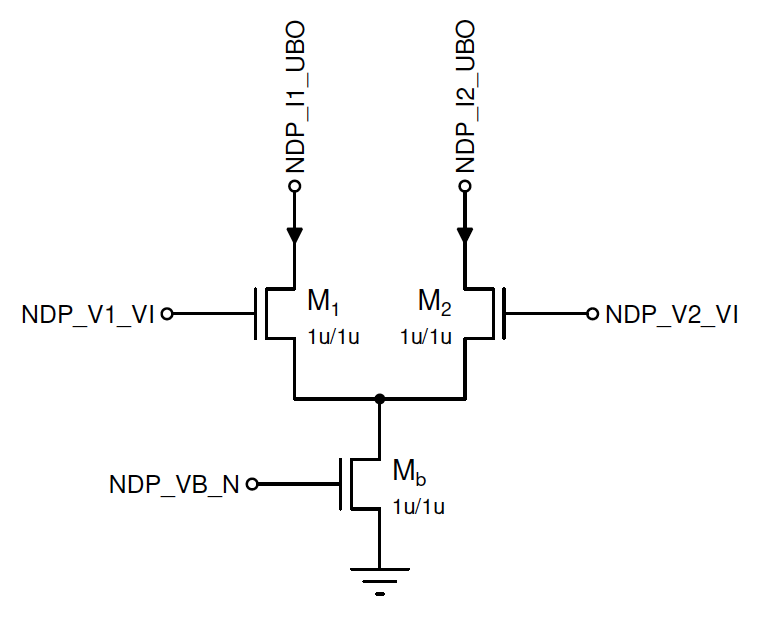

**$I_1$ = NDP_I1_UBO = C2F[0]**

**$I_2$ = NDP_I2_UBO = C2F[1]**

**$V_1$ = NDP_V1_VI = AIN5**

**$V_2$ = NDP_V2_VI = AIN6**

## 5.1 Chip configuration

In [2]:
p.setup_ndp() # sets the biases and sets up the C2F circuits
# you can now use the functions set_ndp_v1(v1) and set_ndp_v2(v2) to set the input voltages
# and use the C2F function 


[INFO]: 2025-10-20 10:17:37,164 - NE1 - Opened CoACH at /dev/cu.usbmodem76219301 with firmware version (1, 12, 5) (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 175, in open)


## 5.2 C2F calibration

Assume the W/L ratio between the differential pair bias transistor Mb and the BiasGen output transistor is **1**.

Using KCL

$I_1+I_2 = I_b \Rightarrow I_1 = I_b - I_2$.

By setting either V1 or V2 much larger than the other, all the bias current $I_b$ will flow down the corresponding branch. That way, we can calibrate the corresponding C2F by sweeping $I_b$ while putting a big differential voltage on the input.

The mapping between $I_1$ and $f_1$ can be obtained by evaluating $V_1 \gg V_2$ and measuring $f_1$ over a range of bias currents $I_b$.

### 5.2.1 Calibrate C2F response for $I_1$ and $I_2$

* Set fixed voltages for $V_1$ and $V_2$. Choose values such that $|V_1 -V_2| \gg 4 U_T$, e.g. 400mV.
* <font color=#108ee9>Capture the calibration data.</font>

[INFO]: 2025-10-20 10:23:58,996 - NE1 - Opened CoACH at /dev/cu.usbmodem76219301 with firmware version (1, 12, 5) (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 175, in open)
[INFO]: 2025-10-20 10:24:07,079 - NE1 - closing device (deleting pyplane.Plane() object (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 250, in close)


I1 freqs: [76, 385, 677, 923, 1224, 1497, 1775, 2014, 2283, 2554, 2795, 3060, 3317, 3514, 3773, 4026, 4249]
I2 freqs: [70, 353, 616, 846, 1119, 1362, 1621, 1845, 2089, 2335, 2562, 2788, 3060, 3228, 3478, 3712, 3922]


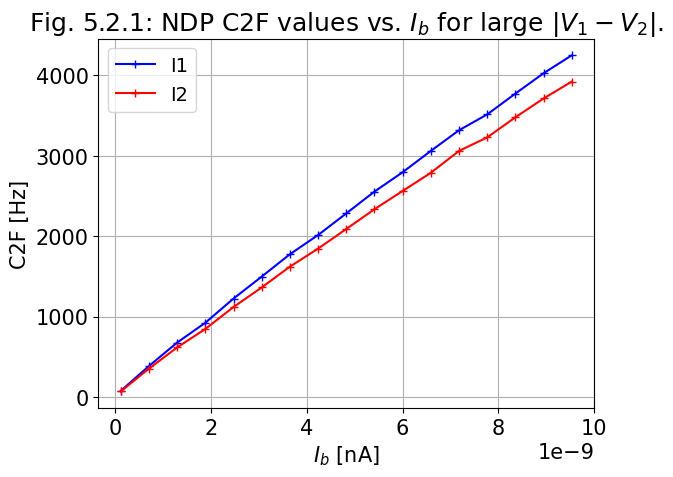

In [4]:
p=Coach(logging_level=logging.INFO)
p.open()
p.setup_ndp()

fine_values = np.arange(1,85,5) # bias current sweep range, a fraction of 255 stepped by last argument

Ib_cal=[]
c2f_calI1 = []
c2f_calI2 = []
vp=.6 # the high input
vn=.2 # the low input
# vp - vn gives us the differential voltage and is greater than 4UT
settle=.1 # time to settle after changing bias or swapping gate voltages
meas_duration=.1

for n in range(len(fine_values)):
    
    # set the Vb bias of the n-type diff pair, which is an n-type bias, using the specified coarse range and fine fraction
    current=p.set_bias(\
        pyplane.Coach.BiasAddress.NDP_VB_N,\
        pyplane.Coach.BiasType.N, \
        pyplane.Coach.BiasGenMasterCurrent.I30nA, int(fine_values[n]))
    Ib_cal.append(current)
 
    p.set_ndp_v1(vp) 
    p.set_ndp_v2(vn)  # steer Ib to I1
    time.sleep(settle) # settle time
    c2f_freqs=p.measure_c2f_freqs(meas_duration)  # read c2f values for 0.1s duration
    # p.read_c2f_freq returns a 16-array of frequencies, we select the one we want here
    c2f_calI1.append(c2f_freqs[p.NDP_I1_C2F_CHANNEL]) # element 0 is the I1 C2F frequency 

    p.set_ndp_v1(vn) 
    p.set_ndp_v2(vp)  # steer Ib to I2
    time.sleep(settle) # settle time
    c2f_freqs=p.measure_c2f_freqs(meas_duration)
    c2f_calI2.append(c2f_freqs[p.NDP_I2_C2F_CHANNEL]) # element 1 is the I2 C2F frequency
p.close()
print(f'I1 freqs: {c2f_calI1}')
print(f'I2 freqs: {c2f_calI2}')
plt.rcParams.update({'font.size': 15})

plt.plot(Ib_cal,c2f_calI1,'b+-')
plt.plot(Ib_cal,c2f_calI2,'r+-')

plt.xlabel('$I_b$ [nA]')
plt.ylabel('C2F [Hz]')
plt.legend(['I1','I2'],prop={'size': 14})
plt.title('Fig. 5.2.1: NDP C2F values vs. $I_b$ for large $|V_1 - V_2|$.')
plt.grid()
plt.show()

* <font color=#108ee9>Plot C2F value vs Ib</font>
* You can follow the example below (but remember to save data first)


In [22]:
savevars(datapath/'lab4_5.2.1')

[INFO]: 2025-10-20 10:43:24,626 - saveloadvars - Saved to data/lab4/lab4_5.2.1 variables [ datapath fine_values Ib_cal c2f_calI1 c2f_calI2 vp vn settle meas_duration n current c2f_freqs I1cal I2cal I1 I2 ] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-10-20 10:43:24,627 - saveloadvars - could not pickle: ['p'] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [ ]:
# loadvars(datapath/'lab4')


Extract the function $I_1\left(f_1\right)$ (Hint: use higher order polynomial to increase accuracy)
* You can follow the example below

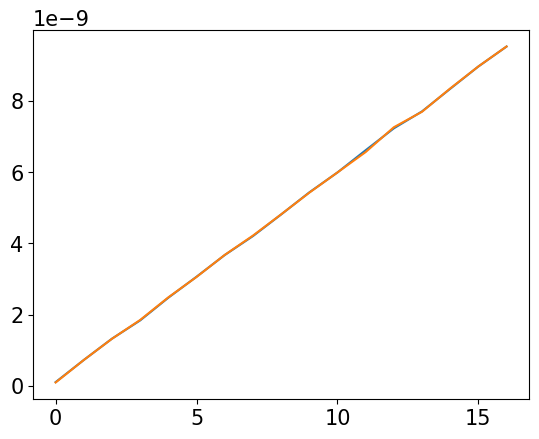

In [ ]:
# fit quadratic polynomial to C2F vs Ib data
# NOTE here we polyfit(y=freq,x=current), not the usual polyfit(x,y), because we want to use the fit to compute x from y, i.e., compute current from frequency
I1cal = np.polyfit(c2f_calI1,Ib_cal,2) # returns a vector of polynomial factors starting with highest order
I2cal = np.polyfit(c2f_calI2,Ib_cal,2) # returns a vector of polynomial factors starting with highest order

def f2i(freq,fit): #define a function to use for converting freq to current given a polyfit
    """ Computes the currents corresponding to C2F frequencies given a polynomial fit
    :param freq: the array of frequencies in Hz
    :param fit: the polynomial fit from np.polyfit
    :return: the array of currents
    """
    freq_arr=np.array(freq)
    
    i = np.polyval(fit,freq) # fit[0]+fit[1]*freq_arr+fit[2]*freq_arr**2
    return i

I1 = f2i(c2f_calI1,I1cal)
I2 = f2i(c2f_calI2,I2cal)

# ploting the current I1
plt.plot(I1)
plt.plot(I2)

## 5.3 Diff pair output currents measurement

Now that you have C2F calibration, you are finally ready to measure the output currents as a function of differential input voltage. 

To do this you will sweep both $V_1$ and $V_2$ in opposite directions around a commmon-mode voltage $V_{\rm cm}$ 

* Set bias current $I_b$ (Hint: linear range $I \le 10$ nA)

In [23]:
Ib=p.set_bias(\
   pyplane.Coach.BiasAddress.NDP_VB_N, \
   pyplane.Coach.BiasType.N, \
   pyplane.Coach.BiasGenMasterCurrent.I30nA, 50)
print(f'The Ib current is set to {ef(Ib)}A')

[INFO]: 2025-10-20 10:44:25,660 - NE1 - Opened CoACH at /dev/cu.usbmodem76219301 with firmware version (1, 12, 5) (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 175, in open)


The Ib current is set to 5.88nA


The bias current is set to

$I_b = w\dfrac{BG_{\text{fine}}}{256}I_{BG_{\text{master}}} = \dfrac{50}{256}\cdot 30\text{nA} \approx 5.859\text{nA}$.

* Data acquisition 
* You can follow the example below

In [ ]:
Vcm_bm = 0.9 # the common-mode voltage
v_range=np.arange(-.3,.3,5e-3) # range of differential inputs
V1_Vcm_bm = Vcm_bm+v_range/2 # V1 sweep range
V2_Vcm_bm = Vcm_bm-v_range/2 # V2 sweep range

V1_Vcm_bm_set = []
V2_Vcm_bm_set = []
c2f_Vcm_I1_bm = []
c2f_Vcm_I2_bm = []

from tqdm import tqdm # import the nice library to show progress bar
for n in tqdm(range(len(V1_Vcm_bm))):
  
    # set V1 and V2 and record the quantized DAC values as our inputs
    V1_Vcm_bm_set.append(p.set_ndp_v1(V1_Vcm_bm[n])) # V1
    V2_Vcm_bm_set.append(p.set_ndp_v2(V2_Vcm_bm[n])) # V2 
    time.sleep(0.1) # settle time
    # read c2f values 
    bab_c2f_freqs = p.measure_c2f_freqs(0.1) # this call to low level pyplane function returns an array of event count values
    c2f_Vcm_I1_bm.append(bab_c2f_freqs[0])
    c2f_Vcm_I2_bm.append(bab_c2f_freqs[1])


100%|██████████| 120/120 [00:24<00:00,  4.81it/s]


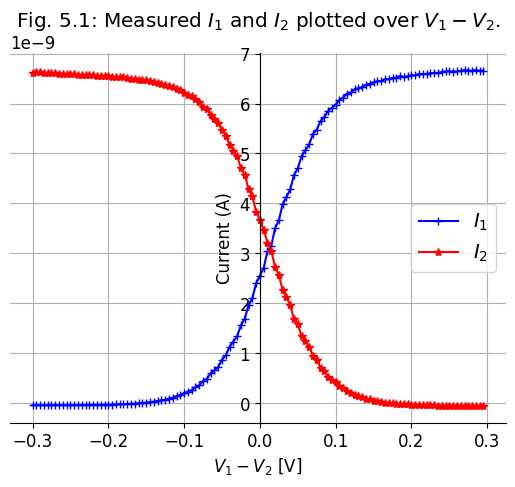

In [26]:

# compute the calibrated I1 and I2 from freqs
I1_bm=f2i(c2f_Vcm_I1_bm,I1cal)
I2_bm=f2i(c2f_Vcm_I2_bm,I2cal)

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

range_V1V2_bm = V1_Vcm_bm - V2_Vcm_bm

# plot with x-axis in middle as appropriate for this data
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
plt.plot(v_range,I1_bm, 'b+-',v_range,I2_bm,'r*-')

#spine placement data centered
# https://stackoverflow.com/questions/31556446/how-to-draw-axis-in-the-middle-of-the-figure
ax.spines['left'].set_position(('data', 0.0))
# ax.spines['bottom'].set_position(('data', 0.0))
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

plt.xlabel('$V_1-V_2$ [V]')
plt.ylabel('Current (A)')
plt.legend(['$I_1$','$I_2$'],prop={'size': 14})
plt.title('Fig. 5.1: Measured $I_1$ and $I_2$ plotted over $V_1-V_2$.')
plt.grid()
plt.show()


* <font color=#108ee9>Save your precious data?</font>

In [29]:
savevars(datapath/'lab4_5.3')

[INFO]: 2025-10-20 10:49:55,131 - saveloadvars - Saved to data/lab4/lab4_5.3 variables [ datapath fine_values Ib_cal c2f_calI1 c2f_calI2 vp vn settle meas_duration n current c2f_freqs I1cal I2cal I1 I2 Ib Vcm_bm v_range V1_Vcm_bm V2_Vcm_bm V1_Vcm_bm_set V2_Vcm_bm_set c2f_Vcm_I1_bm c2f_Vcm_I2_bm bab_c2f_freqs I1_bm I2_bm range_V1V2_bm fig ax ] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-10-20 10:49:55,132 - saveloadvars - could not pickle: ['p'] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


* Now plot all combinations, so you can see if the currents sum to $I_b$ and so you can see the differential current ($I_1$, $I_2$, $I_1 + I_2$, $I_1 - I_2$)
* You can follow the example below

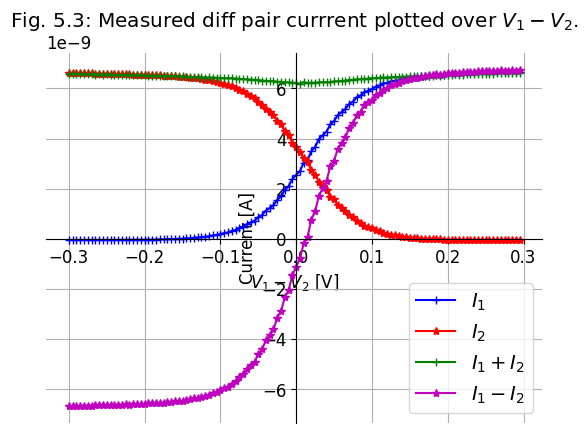

In [28]:
# plot with x-axis in middle as appropriate for this data
# https://stackoverflow.com/questions/31556446/how-to-draw-axis-in-the-middle-of-the-figure
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
plt.plot(v_range,I1_bm, 'b+-',v_range,I2_bm,'r*-', v_range,I1_bm+I2_bm, 'g+-',v_range,I1_bm-I2_bm,'m*-')

#spine placement data centered
ax.spines['left'].set_position(('data', 0.0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

plt.xlabel('$V_1-V_2$ [V]')
plt.ylabel('Current [A]')
plt.legend(['$I_1$','$I_2$','$I_1+I_2$','$I_1-I_2$'],prop={'size': 14})
plt.title('Fig. 5.3: Measured diff pair currrent plotted over $V_1-V_2$.')
plt.grid()
plt.show()

## 5.3.1 Diff pair Analysis

* <font color=#108ee9> Add theoretical plots of the currents to the Fig. 5.3 plots</font>.

<font color=#800080>For clarity, we just add the </font> $I_{\rm out}$<font color=#800080> plot.</font>


Text(0.5, 1.0, 'Fig. 5.3: Measured diff pair current plotted over $V_1-V_2$.')

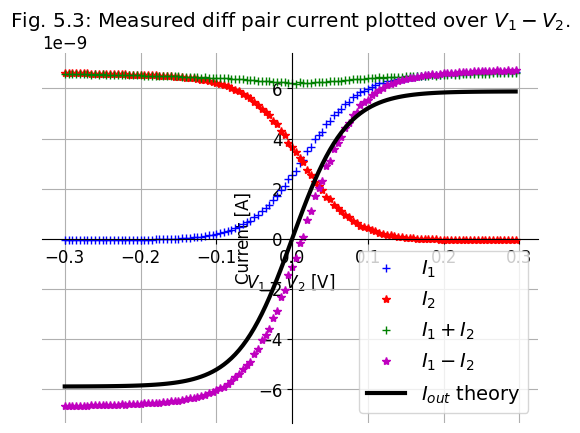

In [31]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
plt.plot(v_range,I1_bm, 'b+',v_range,I2_bm,'r*', v_range,I1_bm+I2_bm, 'g+',v_range,I1_bm-I2_bm,'m*')

#spine placement data centered
ax.spines['left'].set_position(('data', 0.0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

plt.xlabel('$V_1-V_2$ [V]')
plt.ylabel('Current [A]')

plt.grid()


ut=25e-3
ib=Ib
k=.7
itanh=ib*np.tanh( (k*v_range) / (2*ut) )

plt.plot(v_range,itanh,'k', linewidth=3)
plt.legend(['$I_1$','$I_2$','$I_1+I_2$','$I_1-I_2$','$I_{out}$ theory'],prop={'size': 14})
plt.title('Fig. 5.3: Measured diff pair current plotted over $V_1-V_2$.')


* <font color=#108ee9>Comment on any differences you see between measurement and theory. </font>


<font color=#800080>

</font>

* <font color=#108ee9>Comment on the range of linearity and on the measured offset voltage (the voltage that makes $I_1 = I_2$).</font>

* <font color=#108ee9>What determines the linear range of input voltage?</font>

<font color=#800080>

</font>

* <font color=#108ee9>If you were to run the differential pair in strong inversion, what voltage would determine the linear range of operation?</font> _Hint:_ In weak inversion the thermal voltage is the natural voltage scale. In strong inversion, what is the most natural voltage scale?

<font color=#800080>

</font>

## 5.4 More diff pair characterizations.
<font color=#108ee9>Choose one of the following 5.4.X experiments.</font>

For convenience we wrote a method to capture the NPD output.


### 5.4.1  Compare differential sweep with a one-sided sweep
I.e. hold $V_2$ constant and sweep $V_1$ from below $V_2$ to above it). 

* Compare results on same plot. You can just plot $I_1$ and $I_2$. 
You may see something interesting.
* Comment on your results.


[INFO]: 2025-10-20 10:56:50,436 - NE1 - Opened CoACH at /dev/cu.usbmodem76219301 with firmware version (1, 12, 5) (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 175, in open)
100it [00:20,  4.83it/s]


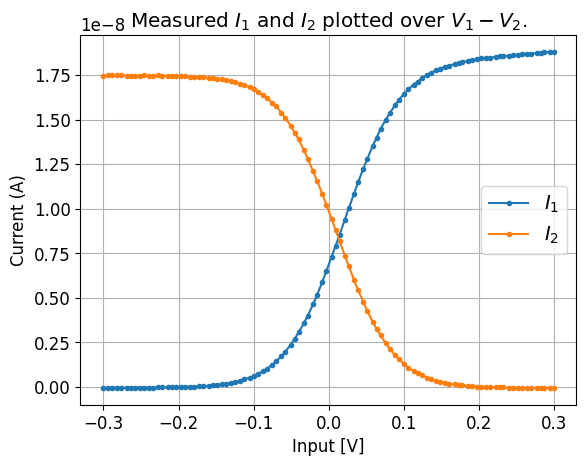

[INFO]: 2025-10-20 10:57:11,297 - NE1 - closing device (deleting pyplane.Plane() object (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 250, in close)


In [33]:
# we define a function to capture the data for each experiment in one shot
# NOTE it depends on I1cal and I2cal existing from before, along with f2i() function
from typing import Optional, Union
def capture_ndp(p:Coach, coarse:pyplane.Coach.BiasGenMasterCurrent, fine:int, v1:Union[float,np.ndarray], v2:Union[float,np.ndarray], i1cal:np.ndarray, i2cal:np.ndarray):
    """Captures the i1 and i2 data and returns them along with bias current value

    :param coach: the Coach() object
    :param coarse: coarse current
    :param fine: fine bias
    :param v1: v1 scalar or vector
    :param v2: v2 scalar or vector (same size as v1 in that case)
    :param i1cal: calibration for i1
    :param i2cal: calibration for i2

    :return: i1,i2,v1,v2,ib
        the returned voltages are the ones that got set (quantized)
    """
    assert not (isinstance(v1,float) and isinstance(v2,float)), "either v1 or v2 or both needs to be array"
    def f2i(freq,fit): #define a function to use for converting freq to current given a polyfit
        """ Computes the currents corresponding to C2F frequencies given a polynomial fit
        :param freq: the array of frequencies in Hz
        :param fit: the polynomial fit from np.polyfit
        :return: the array of currents
        """
        freq_arr=np.array(freq)
        
        i = np.polyval(fit,freq) # fit[0]+fit[1]*freq_arr+fit[2]*freq_arr**2
        return i

    v1sweep=False 
    v2sweep=False
    if isinstance(v1,np.ndarray): 
        v1sweep=True
        vrange=v1
        v2_set=p.set_ndp_v2(v2)
        v1_set = []
    elif isinstance(v2,np.ndarray): 
        v2sweep=True
        vrange=v2
        v1_set=p.set_ndp_v1(v1)
        v2_set = []
    else:
        raise ValueError('neither v1 or v2 is vector')

    i1 = []
    i2 = []
    ib=p.set_ndp_ib(coarse,fine)
    
    from tqdm import tqdm
    for i,v in tqdm(enumerate(vrange)):
        if v1sweep:
            v1_set.append(p.set_ndp_v1(v))
        else:
            v2_set.append(p.set_ndp_v2(v))
        time.sleep(.1)
        fs = p.measure_c2f_freqs(0.1) # this call to low level pyplane function returns an array of event count values
        i1.append(f2i(fs[p.NDP_I1_C2F_CHANNEL],i1cal))
        i2.append(f2i(fs[p.NDP_I2_C2F_CHANNEL],i2cal))

    if v1sweep: v1_set=np.array(v1_set)
    if v2sweep: v2_set=np.array(v2_set)
    i1=np.array(i1)
    i2=np.array(i2)

    dv=v1_set-v2_set
    import matplotlib.pyplot as plt
    plt.rcParams.update({'font.size': 12})

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.plot(dv,i1,'.-',dv,i2,'.-')
    # ax.spines['left'].set_position(('data', 0.0))
    # ax.spines['bottom'].set_position(('data', 0.0))
    # ax.spines['right'].set_color('none')
    # ax.spines['top'].set_color('none')

    plt.xlabel('Input [V]')
    plt.ylabel('Current (A)')
    plt.legend(['$I_1$','$I_2$'],prop={'size': 14})
    plt.title('Measured $I_1$ and $I_2$ plotted over $V_1-V_2$.')
    plt.grid()
    plt.show()

    return i1,i2,v1_set,v2_set,ib

# test it
# loadvars(datapath/'lab4',overwrite='yes') # load calibration data
v2=1
v1=np.linspace(.7,1.3,100)
p=Coach(logging_level=logging.INFO)
p.open()
try:
    i1,i2,v1,v2,ib=capture_ndp(p,pyplane.Coach.BiasGenMasterCurrent.I30nA,127,v1,v2,I1cal,I2cal)
finally:
    p.close()
    

In [34]:
savevars(datapath/'lab4_5.4.1',overwrite='yes')

[INFO]: 2025-10-20 10:58:55,802 - saveloadvars - Saved to data/lab4/lab4_5.4.1 variables [ datapath fine_values Ib_cal c2f_calI1 c2f_calI2 vp vn settle meas_duration n current c2f_freqs I1cal I2cal I1 I2 Ib Vcm_bm v_range V1_Vcm_bm V2_Vcm_bm V1_Vcm_bm_set V2_Vcm_bm_set c2f_Vcm_I1_bm c2f_Vcm_I2_bm bab_c2f_freqs I1_bm I2_bm range_V1V2_bm fig ax ut ib k itanh v2 v1 i1 i2 ] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-10-20 10:58:55,803 - saveloadvars - could not pickle: ['p'] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [35]:
p.close()

### 5.4.2 Repeat the measurement for a larger (superthreshold) value of $I_b$
* Plot the results together and comment
* Is the linear range larger? If so, why?

In [39]:
Ib=p.set_bias(\
   pyplane.Coach.BiasAddress.NDP_VB_N, \
   pyplane.Coach.BiasType.N, \
   pyplane.Coach.BiasGenMasterCurrent.I30nA, 255)
print(f'The Ib current is set to {ef(Ib)}A')

The Ib current is set to 30nA


[INFO]: 2025-10-20 11:02:10,689 - NE1 - was already open (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 145, in open)
100it [00:20,  4.84it/s]


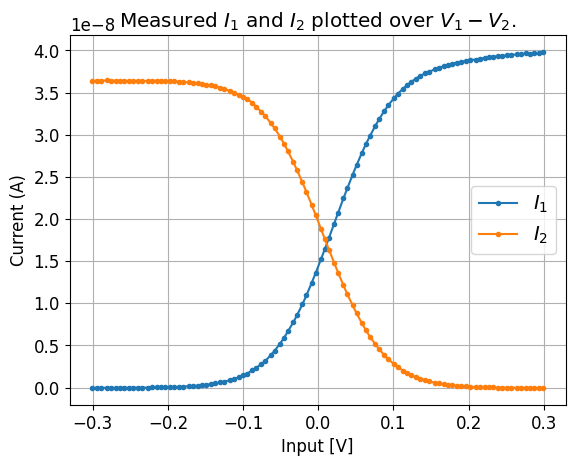

[INFO]: 2025-10-20 11:02:31,475 - NE1 - closing device (deleting pyplane.Plane() object (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 250, in close)


In [40]:
# we define a function to capture the data for each experiment in one shot
# NOTE it depends on I1cal and I2cal existing from before, along with f2i() function
from typing import Optional, Union
def capture_ndp(p:Coach, coarse:pyplane.Coach.BiasGenMasterCurrent, fine:int, v1:Union[float,np.ndarray], v2:Union[float,np.ndarray], i1cal:np.ndarray, i2cal:np.ndarray):
    """Captures the i1 and i2 data and returns them along with bias current value

    :param coach: the Coach() object
    :param coarse: coarse current
    :param fine: fine bias
    :param v1: v1 scalar or vector
    :param v2: v2 scalar or vector (same size as v1 in that case)
    :param i1cal: calibration for i1
    :param i2cal: calibration for i2

    :return: i1,i2,v1,v2,ib
        the returned voltages are the ones that got set (quantized)
    """
    assert not (isinstance(v1,float) and isinstance(v2,float)), "either v1 or v2 or both needs to be array"
    def f2i(freq,fit): #define a function to use for converting freq to current given a polyfit
        """ Computes the currents corresponding to C2F frequencies given a polynomial fit
        :param freq: the array of frequencies in Hz
        :param fit: the polynomial fit from np.polyfit
        :return: the array of currents
        """
        freq_arr=np.array(freq)
        
        i = np.polyval(fit,freq) # fit[0]+fit[1]*freq_arr+fit[2]*freq_arr**2
        return i

    v1sweep=False 
    v2sweep=False
    if isinstance(v1,np.ndarray): 
        v1sweep=True
        vrange=v1
        v2_set=p.set_ndp_v2(v2)
        v1_set = []
    elif isinstance(v2,np.ndarray): 
        v2sweep=True
        vrange=v2
        v1_set=p.set_ndp_v1(v1)
        v2_set = []
    else:
        raise ValueError('neither v1 or v2 is vector')

    i1 = []
    i2 = []
    ib=p.set_ndp_ib(coarse,fine)
    
    from tqdm import tqdm
    for i,v in tqdm(enumerate(vrange)):
        if v1sweep:
            v1_set.append(p.set_ndp_v1(v))
        else:
            v2_set.append(p.set_ndp_v2(v))
        time.sleep(.1)
        fs = p.measure_c2f_freqs(0.1) # this call to low level pyplane function returns an array of event count values
        i1.append(f2i(fs[p.NDP_I1_C2F_CHANNEL],i1cal))
        i2.append(f2i(fs[p.NDP_I2_C2F_CHANNEL],i2cal))

    if v1sweep: v1_set=np.array(v1_set)
    if v2sweep: v2_set=np.array(v2_set)
    i1=np.array(i1)
    i2=np.array(i2)

    dv=v1_set-v2_set
    import matplotlib.pyplot as plt
    plt.rcParams.update({'font.size': 12})

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.plot(dv,i1,'.-',dv,i2,'.-')
    # ax.spines['left'].set_position(('data', 0.0))
    # ax.spines['bottom'].set_position(('data', 0.0))
    # ax.spines['right'].set_color('none')
    # ax.spines['top'].set_color('none')

    plt.xlabel('Input [V]')
    plt.ylabel('Current (A)')
    plt.legend(['$I_1$','$I_2$'],prop={'size': 14})
    plt.title('Measured $I_1$ and $I_2$ plotted over $V_1-V_2$.')
    plt.grid()
    plt.show()

    return i1,i2,v1_set,v2_set,ib

# test it
# loadvars(datapath/'lab4',overwrite='yes') # load calibration data
v2=1
v1=np.linspace(.7,1.3,100)
p=Coach(logging_level=logging.INFO)
p.open()
try:
    i1,i2,v1,v2,ib=capture_ndp(p,pyplane.Coach.BiasGenMasterCurrent.I30nA,255,v1,v2,I1cal,I2cal)
finally:
    p.close()
    

### 5.4.3 Sensitivity to input common mode
Repeat the measurement for two different values of $V_{cm}$, one larger and one smaller than your original value.

With a larger $V_{cm}$, then the diff pair should still work fine (but you should see an effect that you should explain). 
With a small  $V_{cm}$ (smaller than $V_b$), you might run into the "$V_{\rm min}$" problem (if you use a one-sided sweep).  
* Plot the results together and comment.

[INFO]: 2025-10-20 11:20:11,054 - NE1 - Opened CoACH at /dev/cu.usbmodem76219301 with firmware version (1, 12, 5) (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 175, in open)
[INFO]: 2025-10-20 11:20:52,389 - NE1 - closing device (deleting pyplane.Plane() object (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 250, in close)


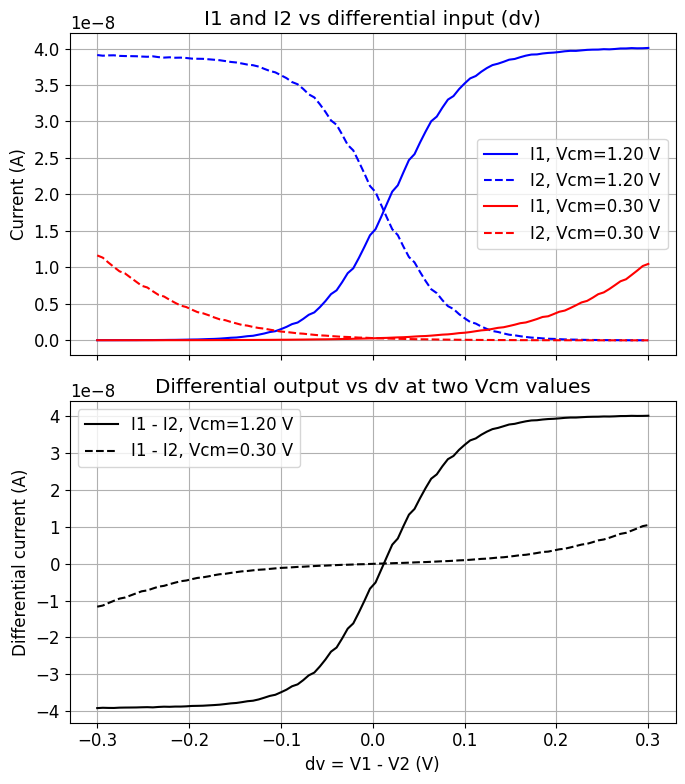

In [47]:
def f2i(freq,fit): #define a function to use for converting freq to current given a polyfit
        """ Computes the currents corresponding to C2F frequencies given a polynomial fit
        :param freq: the array of frequencies in Hz
        :param fit: the polynomial fit from np.polyfit
        :return: the array of currents
        """
        freq_arr=np.array(freq)
        
        i = np.polyval(fit,freq) # fit[0]+fit[1]*freq_arr+fit[2]*freq_arr**2
        return i

def capture_ndp_differential(p, coarse, fine: int, dv: np.ndarray, vcm: float,
                             i1cal: np.ndarray, i2cal: np.ndarray):
    """
    Perform a true differential sweep keeping common-mode fixed: v1 = vcm + dv/2, v2 = vcm - dv/2.

    Returns (i1, i2, v1_set, v2_set, ib) where v*_set are the quantized voltages actually set.
    """
    dv = np.asarray(dv, dtype=float)
    v1_vec = vcm + 0.5 * dv
    v2_vec = vcm - 0.5 * dv

    i1_list = []
    i2_list = []
    v1_set_list = []
    v2_set_list = []

    ib = p.set_ndp_ib(coarse, fine)

    for v1, v2 in zip(v1_vec, v2_vec):
        v1_set_list.append(p.set_ndp_v1(v1))
        v2_set_list.append(p.set_ndp_v2(v2))
        time.sleep(0.1)
        fs = p.measure_c2f_freqs(0.1)
        i1_list.append(f2i(fs[p.NDP_I1_C2F_CHANNEL], i1cal))
        i2_list.append(f2i(fs[p.NDP_I2_C2F_CHANNEL], i2cal))

    i1 = np.asarray(i1_list)
    i2 = np.asarray(i2_list)
    v1_set = np.asarray(v1_set_list)
    v2_set = np.asarray(v2_set_list)

    return i1, i2, v1_set, v2_set, ib


# ==== 5.4.3 Sensitivity to input common-mode: run two Vcm values and overlay ====
# Configure your sweep. Adjust dv range and Vcm values for your setup if needed.
dv = np.linspace(-0.30, 0.30, 100)  # differential input sweep V1-V2
vcm_high = 1.2
vcm_low = 0.30  # choose small enough to potentially observe the Vmin effect

coarse = pyplane.Coach.BiasGenMasterCurrent.I30nA
fine = 255

plt.rcParams.update({"font.size": 12})

p = Coach(logging_level=logging.INFO)
p.open()
try:
    i1_hi, i2_hi, v1_hi, v2_hi, ib_hi = capture_ndp_differential(
        p, coarse, fine, dv, vcm_high, I1cal, I2cal
    )
    i1_lo, i2_lo, v1_lo, v2_lo, ib_lo = capture_ndp_differential(
        p, coarse, fine, dv, vcm_low, I1cal, I2cal
    )
finally:
    p.close()

# Plot overlays: I1/I2 vs dv and the differential current vs dv
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

axes[0].plot(dv, i1_hi, "b-", label=f"I1, Vcm={vcm_high:.2f} V")
axes[0].plot(dv, i2_hi, "b--", label=f"I2, Vcm={vcm_high:.2f} V")
axes[0].plot(dv, i1_lo, "r-", label=f"I1, Vcm={vcm_low:.2f} V")
axes[0].plot(dv, i2_lo, "r--", label=f"I2, Vcm={vcm_low:.2f} V")
axes[0].set_ylabel("Current (A)")
axes[0].set_title("I1 and I2 vs differential input (dv)")
axes[0].grid(True)
axes[0].legend(loc="best")

axes[1].plot(dv, i1_hi - i2_hi, "k-", label=f"I1 - I2, Vcm={vcm_high:.2f} V")
axes[1].plot(dv, i1_lo - i2_lo, "k--", label=f"I1 - I2, Vcm={vcm_low:.2f} V")
axes[1].set_xlabel("dv = V1 - V2 (V)")
axes[1].set_ylabel("Differential current (A)")
axes[1].set_title("Differential output vs dv at two Vcm values")
axes[1].grid(True)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

In [48]:
savevars(datapath/'lab4_5.4.3',overwrite='yes')

[INFO]: 2025-10-20 11:22:38,514 - saveloadvars - Saved to data/lab4/lab4_5.4.3 variables [ datapath fine_values Ib_cal c2f_calI1 c2f_calI2 vp vn settle meas_duration n current c2f_freqs I1cal I2cal I1 I2 Ib Vcm_bm v_range V1_Vcm_bm V2_Vcm_bm V1_Vcm_bm_set V2_Vcm_bm_set c2f_Vcm_I1_bm c2f_Vcm_I2_bm bab_c2f_freqs I1_bm I2_bm range_V1V2_bm fig ax ut ib k itanh v2 v1 i1 i2 dv vcm_high vcm_low coarse fine i1_hi i2_hi v1_hi v2_hi ib_hi i1_lo i2_lo v1_lo v2_lo ib_lo axes ] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-10-20 11:22:38,515 - saveloadvars - could not pickle: ['p'] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


# 6 Bump-antibump circuit (BAB)

In this experiment, we will measure the input-output relationship of the bump-antibump circuit.

The measurements are very similar except for the calibration of the middle branch output current $I_{\rm mid}$. We cannot make it be all of $I_b$, so we need to infer its calibration from the $I_1$ and $I_2$ calibrations and our bias value of $I_b$.

## 6.0 Schematic and pin map

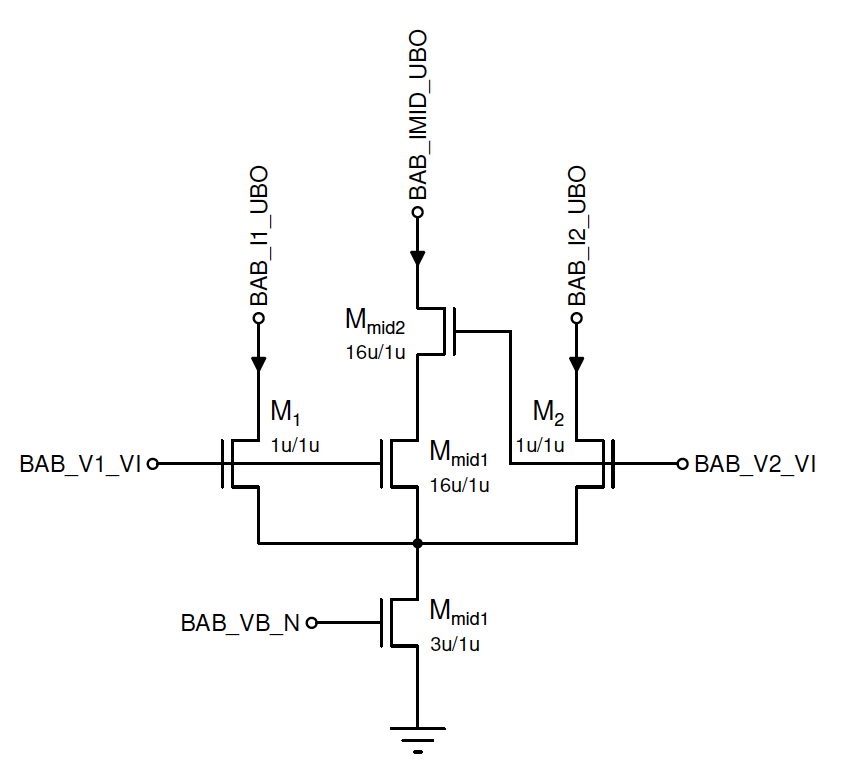

**$I_1$ = BAB_I1_UBO = C2F[5]**

**$I_2$ = BAB_I2_UBO = C2F[6]**

**$I_{out}$ = BAB_IMID_UBO = C2F[7]**

**$V_1$ = BAB_V1_VI = AIN12**

**$V_2$ = BAB_V2_VI = AIN13**

## 6.1 BAB $I_{\rm out}$ theory

Assume the W/L ratio between the bump-antibump bias transistor Mb and the BiasGen output transistor is **3**.

* If we trust the value for $I_b$ calculated from the BiasGen, how do we find out the mapping between $I$ and $f$ for each C2F channel?

From the schematic of the bump-antibump circuit, it can be inferred that (KCL)

$I_b = I_1 + I_2 + I_{out}$.

As the current $I_1$ becomes far larger than the currents $I_2$ and $I_{out}$ for  $V_1 \gg V_2$ (and the current $I_2$ becomes far larger than the currents $I_1$ and $I_{out}$ for $V_1 \ll V_2$), this property can be utilized to find the mapping between $I_1$ and $f_1(I_b)$ and $I_2$ and $f_2(I_b)$ just as for the NDP. 

We cannot do this for $I_{out}$, because it would require both $I_1$ and $I_2$ to be 0. In this case, $V_1$ and $V_2$ would have to be 0 as well, implying that all gates in the circuit are closed and no currents are flowing. Our actual procedure for $I_{out}$ is decribed later (maybe you can improve it).


## 6.2 BAB C2F calibration

## 6.2.1 Calibrate BAB C2F responses for $I_1$ and $I_2$ as you did for the diff pair. 
The BAB uses different C2F circuits so you need to measure them again. Once again set a large $|V_1-V_2|$ with both signs and measure the $I_1$ and $I_2$ frequencies. That will let you measure the calibration polynomial coefficients `cal` that you can use with the `f2i(cal,freq)` function defined above to compute the currents from the C2F frequencies.

You cannot steer all of $I_b$ to the $I_{\rm out}$ branch, so you cannot calibrate it directly. But you can measure the $I_{\rm out}$ C2F frequency at the same time as you measure the $I_1$ and $I_2$ C2F frequencies. Therefore, once you calibrate $I_1$ and $I_2$, you can use their measured currents to infer the unknown $I_{\rm out}$ current from its C2F frequency.

**NOTE:** For this exercise (since we cannot think of something better; maybe you can), we will just average our $I_1$ and $I_2$ calibrations and use it for the $I_{\rm out}$ calibration. Perhaps you can figure out how to make this better, e.g. by calibrating $I_{\rm out}$ based on the fact that the currents should always sum (neglecting Early effect) to $I_b$.

You can copy and adapt code blocks from above. Watch out for name clashes that will overwrite your previous data. 

You may want to save your precious diff pair data to a different file before starting any BAB measurements.

In [ ]:
savevars(datapath/'lab4_6.2.1')

[INFO]: 2025-10-20 11:28:01,172 - NE1 - was already open (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 145, in open)
100%|██████████| 51/51 [00:23<00:00,  2.17it/s]

I1 freqs: [177, 913, 1627, 2171, 2904, 3570, 4277, 4733, 5401, 6061, 6582, 7213, 7875, 8268, 8923, 9523, 10012, 10620, 11221, 11646, 12263, 12819, 13408, 13852, 14427, 14983, 14670, 15221, 16107, 16972, 18038, 18865, 19555, 20388, 22046, 25419, 34472, 38913, 40155, 40703, 41591, 42398, 43144, 44002, 44789, 45298, 46236, 46963, 47608, 48362, 49122]
I2 freqs: [185, 952, 1698, 2262, 3021, 3709, 4445, 4921, 5607, 6272, 6812, 7458, 8140, 8535, 9214, 9816, 10318, 10939, 11554, 11983, 12597, 13165, 13786, 14217, 14814, 15610, 15222, 16332, 17455, 18127, 19025, 19928, 20990, 25926, 34568, 37638, 39037, 39886, 40846, 41394, 42255, 43133, 43861, 44586, 45287, 46069, 46835, 47613, 48241, 49001, 49772]


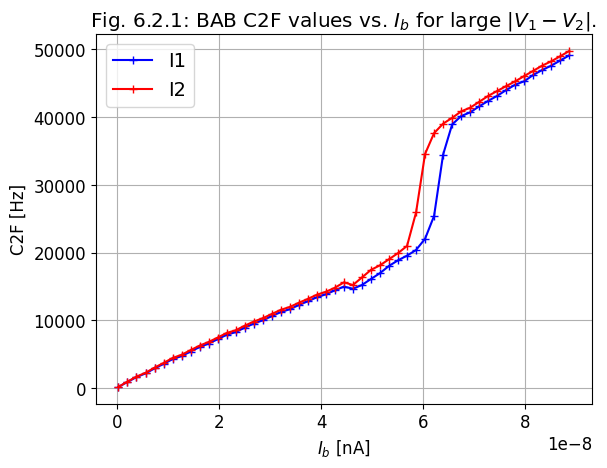

In [50]:
# BAB C2F calibration
p.open()
p.setup_bab()

# some params to make sure they are the same in different code blocks
w_bab=3 # the bias FET W/L ratio relative to biasgen
coarse_current_bab=pyplane.Coach.BiasGenMasterCurrent.I30nA


import numpy as np
fine_values = np.arange(1,255,5) # bias current sweep range, a fraction of 255 stepped by last argument

Ib_cal_bab=[]
c2f_calI1_bab = []
c2f_calI2_bab = []
vp=.6 # the high input
vn=.2 # the low input
settle=.1 # time to settle after changing bias or swapping gate voltages
meas_duration=.1

for n in tqdm(range(len(fine_values))):
    
    # set the Vb bias of the n-type bias, which is an n-type bias, using the specified coarse range and fine fraction
    # note w_bab since this is closer to the true Ib
    current=p.set_bab_ib(coarse_current_bab, int(fine_values[n])) 
    Ib_cal_bab.append(current)
 
    p.set_bab_v1(vp) 
    p.set_bab_v2(vn)  # steer Ib to I1
    time.sleep(settle) # settle time
    c2f_freqs=p.measure_c2f_freqs(meas_duration)  # read c2f values for 0.1s duration
    # p.read_c2f_freq returns a 16-array of frequencies, we select the one we want here
    c2f_calI1_bab.append(c2f_freqs[p.BAB_I1_C2F_CHANNEL]) # element 0 is the I1 C2F frequency 

    p.set_bab_v1(vn) 
    p.set_bab_v2(vp)  # steer Ib to I2
    time.sleep(settle) # settle time
    c2f_freqs=p.measure_c2f_freqs(meas_duration)
    c2f_calI2_bab.append(c2f_freqs[p.BAB_I2_C2F_CHANNEL]) # element 1 is the I2 C2F frequency

print(f'I1 freqs: {c2f_calI1_bab}')
print(f'I2 freqs: {c2f_calI2_bab}')
plt.rcParams.update({'font.size': 12})

plt.plot(Ib_cal_bab,c2f_calI1_bab,'b+-')
plt.plot(Ib_cal_bab,c2f_calI2_bab,'r+-')

plt.xlabel('$I_b$ [nA]')
plt.ylabel('C2F [Hz]')
plt.legend(['I1','I2'],prop={'size': 14})
plt.title('Fig. 6.2.1: BAB C2F values vs. $I_b$ for large $|V_1 - V_2|$.')
plt.grid()
plt.show()

Now fit polynomials to this data to compute the calibration for $I_1$ and $I_2$

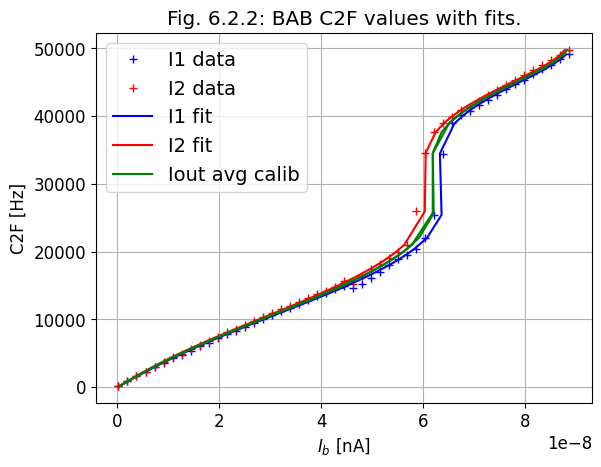

In [51]:
# fit polynomial to C2F vs Ib data
order=6
# note x is frequency, y is current; see the NDP calibration for why we do this.
I1cal_bab = np.polyfit(c2f_calI1_bab,Ib_cal_bab,order) # returns a vector of polynomial factors starting with highest order
I2cal_bab = np.polyfit(c2f_calI2_bab,Ib_cal_bab,order) # returns a vector of polynomial factors starting with highest order
# average these to produce an approximate Iout calibration, we will check it for sanity in plot
Ioutcal_bab=(I1cal_bab+I2cal_bab)/2

# redefine f2i() in case we came here
def f2i(freq,fit): #define a function to use for converting freq to current given a polyfit
    """ Computes the currents corresponding to C2F frequencies given a polynomial fit
    :param freq: the array of frequencies in Hz
    :param fit: the polynomial fit from np.polyfit
    :return: the array of currents
    """
    freq_arr=np.array(freq) # convert to numpy array from possible python array
    
    current = np.polyval(fit,freq) # fit[0]+fit[1]*freq_arr+fit[2]*freq_arr**2
    return current

# check by plotting
# compute the fitted values
# orig data as points
plt.plot(Ib_cal_bab,c2f_calI1_bab,'b+')
plt.plot(Ib_cal_bab,c2f_calI2_bab,'r+')
# fit as lines, NOTE we need to invert the computation to compute the currents from the frequencies
plt.plot(f2i(c2f_calI1_bab, I1cal_bab), c2f_calI1_bab,'b-')
plt.plot(f2i(c2f_calI2_bab, I2cal_bab), c2f_calI2_bab,'r-')
plt.plot(f2i(c2f_calI2_bab, Ioutcal_bab), c2f_calI2_bab,'g-')
plt.plot(f2i(c2f_calI1_bab, Ioutcal_bab), c2f_calI1_bab,'g-')

plt.xlabel('$I_b$ [nA]')
plt.ylabel('C2F [Hz]')
plt.legend(['I1 data','I2 data','I1 fit','I2 fit','Iout avg calib'],prop={'size': 14})
plt.title('Fig. 6.2.2: BAB C2F values with fits.')
plt.grid()
plt.show()



## 6.3 BAB output currents measurement
Finally we are ready to do the actual BAB measurements

Set BAB bias current to $I_{\rm b,bab} = w_{\rm bab}\dfrac{BG_{\text{fine}}}{256}I_{BG_{\text{master}}} = 3\cdot \dfrac{12}{256}\cdot 30\text{nA} \approx 4.219\text{nA}$. (We add the factor $w_{bab}=3$ because the $W/L$ ratio of the bias NFET is 3 and in the biasgen $W/L=1$).

* Measure the c2f frequencies and directly compute the $I_1$, $I_2$, and $I_{\rm out}$ currents from them during the measurement using our calibrations.

You can follow the example below

In [52]:
# your code
Vcm_bm_bab = 0.9 # common mode voltage
V1_Vcm_bm_bab  = np.arange(0.65,1.15,0.005) # V1 sweep range. NOTE this is a one-sided sweep
fine_current_bab=12 # used in actual measurements, this is the fine bias splitter value

V2_Vcm_bm_bab  = []
V1_Vcm_bm_set_bab  = []
V2_Vcm_bm_set_bab  = []
c2f_Vcm_I1_bm_bab  = []
c2f_Vcm_I2_bm_bab  = []
c2f_Vcm_Iout_bm_bab = []
I1_bab=[]
I2_bab=[]
Iout_bab=[]

p.open()
p.setup_bab()

# set bias current
w_bab=3 # the Ib FET in BAB has W/L ratio of 3 compared the W/L ratio of the bias circuit. Its bias current will be larger than the returned bias current by approximately this ratio
Ib_bab = w_bab*p.set_bias(\
   pyplane.Coach.BiasAddress.BAB_VB_N, \
   pyplane.Coach.BiasType.N, \
   coarse_current=coarse_current_bab, fine_value=fine_current_bab)
print(f'The BAB Ib is set to {ef(Ib_bab)}A')

print(f'BAB \tv1 V, \tv2 V, \tI1 A, \t\tI2 A, \tIout A')
for n in range(len(V1_Vcm_bm_bab)):
    
    v1=V1_Vcm_bm_bab[n]
    # NOTE use of assignment here  https://stackoverflow.com/questions/19767891/python-assign-value-to-variable-during-condition-in-while-loop
    V2_Vcm_bm_bab.append(v2:=2*Vcm_bm_bab -v1)
        
    V1_Vcm_bm_set_bab.append(p.set_bab_v1(V1_Vcm_bm_bab[n]))
    V2_Vcm_bm_set_bab.append(p.set_bab_v2(V2_Vcm_bm_bab[n]))
    time.sleep(0.1) # settle time
    
    # read c2f values 
    bab_c2f_freqs = p.measure_c2f_freqs(0.1) 
    c2f_Vcm_I1_bm_bab.append(fi1:=bab_c2f_freqs[p.BAB_I1_C2F_CHANNEL]) # NOTE use of assignment here to fi1
    c2f_Vcm_I2_bm_bab.append(fi2:=bab_c2f_freqs[p.BAB_I2_C2F_CHANNEL])
    c2f_Vcm_Iout_bm_bab.append(fiout:=bab_c2f_freqs[p.BAB_IOUT_C2F_CHANNEL])
    I1_bab.append(i1:=f2i(fi1,I1cal_bab))
    I2_bab.append(i2:=f2i(fi2,I2cal_bab))
    Iout_bab.append(iout:=f2i(fiout,Ioutcal_bab))
    
    print(f'\t{ef(v1)}V, \t{ef(v2)},\t{ef(i1)}, \t{ef(i2)}, \t{ef(iout)}')
I1_bab=np.array(I1_bab)
I2_bab=np.array(I2_bab)
Iout_bab=np.array(Iout_bab) # make np.ndarray so that math can be done with them

[INFO]: 2025-10-20 11:34:31,373 - NE1 - was already open (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 145, in open)


The BAB Ib is set to 4.24nA
BAB 	v1 V, 	v2 V, 	I1 A, 		I2 A, 	Iout A
	650mV, 	1.15,	114.59p, 	4.72n, 	204.13p
	655mV, 	1.14,	112.14p, 	4.72n, 	204.13p
	660mV, 	1.14,	114.59p, 	4.72n, 	204.13p
	665mV, 	1.14,	112.14p, 	4.71n, 	201.84p
	670mV, 	1.13,	114.59p, 	4.71n, 	204.13p
	675mV, 	1.12,	112.14p, 	4.71n, 	204.13p
	680mV, 	1.12,	114.59p, 	4.71n, 	204.13p
	685mV, 	1.12,	112.14p, 	4.70n, 	201.84p
	690mV, 	1.11,	114.59p, 	4.70n, 	204.13p
	695mV, 	1.10,	112.14p, 	4.71n, 	204.13p
	700mV, 	1.10,	114.59p, 	4.70n, 	204.13p
	705mV, 	1.10,	112.14p, 	4.69n, 	204.13p
	710mV, 	1.09,	114.59p, 	4.69n, 	204.13p
	715mV, 	1.08,	112.14p, 	4.69n, 	204.13p
	720mV, 	1.08,	114.59p, 	4.69n, 	206.42p
	725mV, 	1.08,	112.14p, 	4.69n, 	206.42p
	730mV, 	1.07,	114.59p, 	4.68n, 	206.42p
	735mV, 	1.06,	112.14p, 	4.68n, 	206.42p
	740mV, 	1.06,	114.59p, 	4.67n, 	208.71p
	745mV, 	1.06,	114.59p, 	4.67n, 	211p
	750mV, 	1.05,	114.59p, 	4.66n, 	211p
	755mV, 	1.04,	114.59p, 	4.65n, 	215.57p
	760mV, 	1.04,	114.59p, 	4.65n, 	21

In [53]:
p.close()

[INFO]: 2025-10-20 11:35:09,619 - NE1 - closing device (deleting pyplane.Plane() object (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 250, in close)


* <font color=#108ee9>Plot $I_1$, $I_2$, $I_{out}$, $I_1+I_2$, $I_1+I_2+I_{out}$.</font>

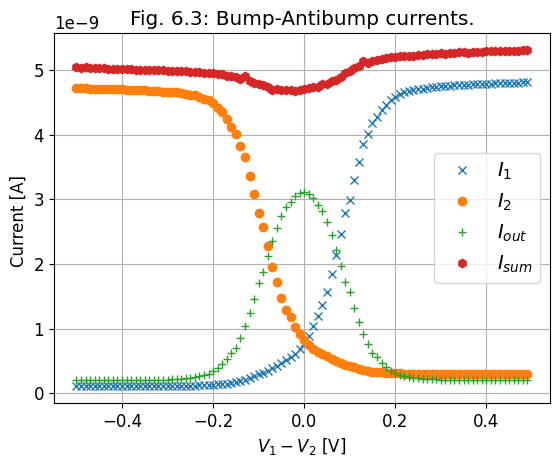

In [54]:
dv=V1_Vcm_bm_bab-V2_Vcm_bm_bab
Isum_bab=I1_bab+I2_bab+Iout_bab

# plot with x-axis in middle as appropriate for this data
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

plt.plot(dv,I1_bab,'x', dv,I2_bab,'o',dv,Iout_bab,'+',dv, Isum_bab,'h')
# #spine placement data centered
# # https://stackoverflow.com/questions/31556446/how-to-draw-axis-in-the-middle-of-the-figure
# ax.spines['left'].set_position(('data', 0.0))
# ax.spines['bottom'].set_position(('data', 0.0))
# ax.spines['right'].set_color('none')
# ax.spines['top'].set_color('none')

plt.xlabel('$V_1-V_2$ [V]')
plt.ylabel('Current [A] ')
plt.legend(['$I_1$','$I_2$','$I_{out}$','$I_{sum}$'],prop={'size': 14})
plt.title('Fig. 6.3: Bump-Antibump currents.')
plt.grid()
plt.show()

* Save your data?

In [58]:
savevars(datapath/'lab4_bab_6.3')

[INFO]: 2025-10-20 11:52:31,858 - saveloadvars - Saved to data/lab4/lab4_bab_6.3 variables [ datapath fine_values Ib_cal c2f_calI1 c2f_calI2 vp vn settle meas_duration n current c2f_freqs I1cal I2cal I1 I2 Ib Vcm_bm v_range V1_Vcm_bm V2_Vcm_bm V1_Vcm_bm_set V2_Vcm_bm_set c2f_Vcm_I1_bm c2f_Vcm_I2_bm bab_c2f_freqs I1_bm I2_bm range_V1V2_bm fig ax ut ib k itanh v2 v1 i1 i2 dv vcm_high vcm_low coarse fine i1_hi i2_hi v1_hi v2_hi ib_hi i1_lo i2_lo v1_lo v2_lo ib_lo axes w_bab coarse_current_bab Ib_cal_bab c2f_calI1_bab c2f_calI2_bab order I1cal_bab I2cal_bab Ioutcal_bab Vcm_bm_bab V1_Vcm_bm_bab fine_current_bab V2_Vcm_bm_bab V1_Vcm_bm_set_bab V2_Vcm_bm_set_bab c2f_Vcm_I1_bm_bab c2f_Vcm_I2_bm_bab c2f_Vcm_Iout_bm_bab I1_bab I2_bab Iout_bab Ib_bab fi1 fi2 fiout iout Isum_bab bab_ratio Iout_bab_theory Iout_max_bab bab_ratio_meas bab_ratio_theory ] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 202

## 6.4 BAB comparison with theory


* You can follow the example below (but you need to change all the variables names)
* Recall the theory
  $I_{out} = I_b \dfrac{r}{r+4\cosh^2\left(\frac{\kappa\Delta V}{2U_T}\right)}$.

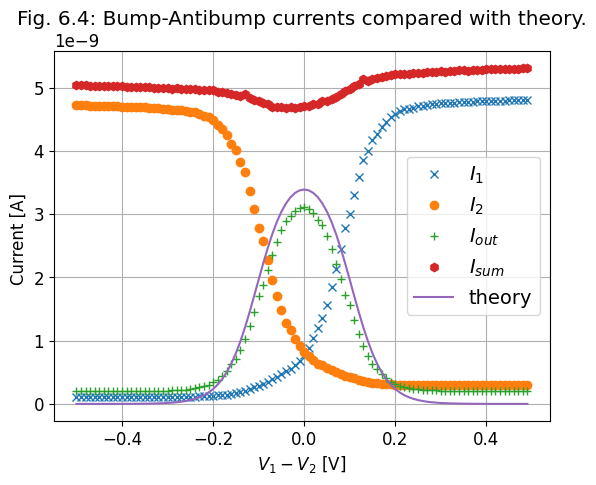

In [56]:
# once again plot the measurement against theory

bab_ratio=16 # from ratio of schematic W/L ratios

def antibump(v,ib,bab_ratio):
    r=bab_ratio # from schematic
    ut=25e-3 # thermal voltage
    kappa=.7 # guesstimate
    iout=ib*(r/(r+4*np.square(np.cosh((kappa*v)/(2*ut)))))
    return iout
Iout_bab_theory=antibump(dv,Ib_bab,bab_ratio)

# plot with x-axis in middle as appropriate for this data
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

plt.plot(dv,I1_bab,'x', dv,I2_bab,'o',dv,Iout_bab,'+',dv, Isum_bab,'h',dv,Iout_bab_theory,'-')
# #spine placement data centered
# # https://stackoverflow.com/questions/31556446/how-to-draw-axis-in-the-middle-of-the-figure
# ax.spines['left'].set_position(('data', 0.0))
# ax.spines['bottom'].set_position(('data', 0.0))
# ax.spines['right'].set_color('none')
# ax.spines['top'].set_color('none')

plt.xlabel('$V_1-V_2$ [V]')
plt.ylabel('Current [A] ')
plt.legend(['$I_1$','$I_2$','$I_{out}$','$I_{sum}$','theory'],prop={'size': 14})
plt.title('Fig. 6.4: Bump-Antibump currents compared with theory.')
plt.grid()
plt.show()


* Compute the actual max $I_{\rm out}$ and remind us the $I_b$ value

In [ ]:

# compute the max value of Iout and print Ib
Iout_max_bab = np.max(Iout_bab)
print(f'Ib_bab={ef(Ib_bab)}A and Iout_max_bab={ef(Iout_max_bab)}A')
bab_ratio_meas = Iout_max_bab/Ib_bab
bab_ratio_theory = bab_ratio/(bab_ratio+4)
print(f'Actual ratio Iout_max/Ib={ef(bab_ratio_meas)}; theory ratio = {ef(bab_ratio_theory)}')

Ib_bab=4.24nA and Iout_max_bab=3.11nA
Actual ratio Iout_max/Ib=733.19m; theory ratio = 800m


* <font color=#108ee9>Based on prelab [Sec. 2.2](#22-bump-antibump-circuit) and the transistor W/L ratios shown in the schematic, does the measured ratio of maximum bump current to bias current accord with your measurement? Comment on possible reasons for any discrepancy between the fit and what you expect from the known transistor geometry. </font>
 
In principle the actual results might be affected by the short and narrow channel effects:


* Narrow-Channel Effect:

This effect occurs when the width $W$ of a transistor is small. Due to the extension of the depletion region underneath the gate toward the sides, some field lines from the gate end in depletion region under the oxide instead of the depletion region underneath the gate. This narrow channel effect increases the perceived threshold voltage.

* Short-Channel Effects:

These effect occur when the length $L$ of a transistor is small, and are mainly the result of the decreased effective channel length from the depletion regions at the source and drain starting to touch. This short channel effect decreases the effective length to be shorter than the drawn length, effectively decreasing the threshold voltage.

In the prelab, it was determined that the bump current assumes its maximum value $I_{out,max}$ when $V_1=V_2$. The corresponding ratio to the bias current $I_b$ is 0.8.

<font color=#800080>

We observed ....

</font>

In [59]:
savevars(datapath/'lab4_bab_6.4')

[INFO]: 2025-10-20 11:54:05,528 - saveloadvars - Saved to data/lab4/lab4_bab_6.4 variables [ datapath fine_values Ib_cal c2f_calI1 c2f_calI2 vp vn settle meas_duration n current c2f_freqs I1cal I2cal I1 I2 Ib Vcm_bm v_range V1_Vcm_bm V2_Vcm_bm V1_Vcm_bm_set V2_Vcm_bm_set c2f_Vcm_I1_bm c2f_Vcm_I2_bm bab_c2f_freqs I1_bm I2_bm range_V1V2_bm fig ax ut ib k itanh v2 v1 i1 i2 dv vcm_high vcm_low coarse fine i1_hi i2_hi v1_hi v2_hi ib_hi i1_lo i2_lo v1_lo v2_lo ib_lo axes w_bab coarse_current_bab Ib_cal_bab c2f_calI1_bab c2f_calI2_bab order I1cal_bab I2cal_bab Ioutcal_bab Vcm_bm_bab V1_Vcm_bm_bab fine_current_bab V2_Vcm_bm_bab V1_Vcm_bm_set_bab V2_Vcm_bm_set_bab c2f_Vcm_I1_bm_bab c2f_Vcm_I2_bm_bab c2f_Vcm_Iout_bm_bab I1_bab I2_bab Iout_bab Ib_bab fi1 fi2 fiout iout Isum_bab bab_ratio Iout_bab_theory Iout_max_bab bab_ratio_meas bab_ratio_theory ] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 202

## Upload your report (this notebook)
<font color=#108ee9>Upload your report to the course dropbox as either HTML or PDF (not ipynb, which is hard for us to assess).</font>

## What we expect you to learn
Please see the [NE1 exam preparation guide](https://drive.google.com/file/d/1nOq3UbcEv_ik425VBYqcH9hAET7FyIeP/view?usp=drive_link)
